Check trained model from LAN_pipeline

In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import ssms
from ssms.basic_simulators.simulator import simulator
import hssm
from hssm.distribution_utils.onnx import onnx as onx
import bambi as bmb
import matplotlib.pyplot as plt
import pickle
from functools import partial
from copy import deepcopy
from helper_functions import *

/users/avo2/mambaforge/envs/hssm_vi2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
    dim_dict = {
        'vh': 'high',
        'vl1': 'irr',
        'vl2': 'low'
    }

    for v in ['vh','vl1','vl2']:
        v_shell = {
            "name": v,
            "prior":
            {"Intercept": {"name": "Normal", "mu": 1, "sigma": 2, "initval": 1},
             dim_dict[v] + 'DimCoh': {"name": "Normal", "mu": 1, "sigma": 1, "initval": 1},
             dim_dict[v] + 'DimCoh|subj_idx' : {"name": "Normal", "mu": 0, "sigma": {"name": "HalfNormal", "sigma": 0.3,
                                                                }},
            "1|subj_idx": {"name": "Normal","mu":  0,
                                                    "sigma": {"name": "HalfNormal", "sigma": 1,
                                                            }, "initval": 0                                                   
            }},

            "formula": v + ' ~ 1 +' +  dim_dict[v] + 'DimCoh + (1 + ' + dim_dict[v] + 'DimCoh|subj_idx)'
            }
        if target_v == v:
            v_shell['prior'][EEG_target] = {"name": "Normal", "mu": 0, "sigma": 1, "initval": 0}
            v_shell['prior'][EEG_target + '|subj_idx'] = {"name": "Normal", "mu": 0, "sigma": {"name": "HalfNormal", "sigma": 0.3,
                                                            }}
            del v_shell['prior'][dim_dict[v] + 'DimCoh|subj_idx']
            v_shell['formula'] = v + ' ~ 1 + ' +  dim_dict[v] + 'DimCoh + ' + EEG_target + ' + (1 + ' + dim_dict[v] + 'DimCoh + ' + EEG_target + '|subj_idx)'
    
             



{'name': 'vh', 'prior': {'Intercept': {'name': 'Normal', 'mu': 1, 'sigma': 2, 'initval': 1}, 'highDimCoh': {'name': 'Normal', 'mu': 1, 'sigma': 1, 'initval': 1}, '1|subj_idx': {'name': 'Normal', 'mu': 0, 'sigma': {'name': 'HalfNormal', 'sigma': 1}, 'initval': 0}, 'lowPos': {'name': 'Normal', 'mu': 0, 'sigma': 1, 'initval': 0}, 'lowPos|subj_idx': {'name': 'Normal', 'mu': 0, 'sigma': {'name': 'HalfNormal', 'sigma': 0.3}}}, 'formula': 'vh ~ 1 +highDimCoh + lowPos + (1 + highDimCoh + lowPos|subj_idx)'}
{'name': 'vl1', 'prior': {'Intercept': {'name': 'Normal', 'mu': 1, 'sigma': 2, 'initval': 1}, 'irrDimCoh': {'name': 'Normal', 'mu': 1, 'sigma': 1, 'initval': 1}, 'irrDimCoh|subj_idx': {'name': 'Normal', 'mu': 0, 'sigma': {'name': 'HalfNormal', 'sigma': 0.3}}, '1|subj_idx': {'name': 'Normal', 'mu': 0, 'sigma': {'name': 'HalfNormal', 'sigma': 1}, 'initval': 0}}, 'formula': 'vl1 ~ 1 +irrDimCoh + (1 + irrDimCoh|subj_idx)'}
{'name': 'vl2', 'prior': {'Intercept': {'name': 'Normal', 'mu': 1, 'sigma

In [3]:
#Load model
path_trainconfig = '/users/avo2/data/avo2/LANminimal/data/networks/torch/lan/mic2_small/mic2_small_lan_fa721f74e63711eea86118c04d7b6328_train_config.pickle'
path_statedict = '/users/avo2/data/avo2/LANminimal/data/networks/torch/lan/mic2_small/mic2_small_lan_fa721f74e63711eea86118c04d7b6328_train_state_dict_torch.pt'
with open(path_trainconfig, 'rb') as handle:
    trainconfig=pickle.load(handle)

model_config = ssms.config.model_config['ddm_mic2_leak_no_bias_no_lowdim_noise']

In [4]:
class ModelPipeline:
    """
    This class is used to generate data based on parameters, fit and graph with HSSM and arviz. Supports 'freezing' certain parameters as scalars.

    Attributes
    -----------
        model_name: str
        model_config: dict

    Methods
    ----------

    Returns
    ----------
    """

    def __init__(self, path_to_onnx, model_name):
        self.path_to_onnx = path_to_onnx
        self.model_name = model_name
        self.model_config = deepcopy(ssms.config.model_config[self.model_name])
        # if model_name == 'ddm_mic2_leak_no_bias_no_lowdim_noise':
        #     self.model_config['params'] = self.model_config['params'][:-1] #currently there's an extra p_outlier param at the end, so we are cutting that out
    def parameter_randomiser(self, set_value_dict = None):
        '''
        Function that generates the relevant parameters to feed to release_params
            set_value_dict: dict
                a dictionary of {name, set value} for any parameters you want to fix


    Return:
      parameter_dict: a dictionary of the parameters

    '''

        #Get the parameter list from ssms
        config = self.model_config
        config_list = config['params']

        param_dict = {}
        for i in range(len(config_list)):
            #Draw a random unif (low,high), then add to dictionary
            param_dict[config_list[i]] = np.random.uniform(config['param_bounds'][0][i], config['param_bounds'][1][i])
        
        #Update the param_dict with set values in the set_value_dict
        if set_value_dict != None:
            for i in set_value_dict.keys():
                param_dict[i] = set_dict[i]

        self.param_dict=param_dict
        return self.param_dict
    
    def dataset_generator(self, fixed_int = [], fixed_coh = [], dataset_size=1000):
        '''
            fixed_coh: 4-itemed list, or empty
                       [high coh vh, low coh vh, high coh vl1, low coh vl1]. Note that the ratio is 50 50
                       
            fixed_int: 2-itemed list, or empty [vh intercept, vl1 intetcept]
        ''' 
        if not fixed_int:
            intercept_vh = np.random.uniform(0,1)
            intercept_vl1 = np.random.uniform(0,1)
            intercept_vl2 = np.random.uniform(0,1)
        else:
            intercept_vh = fixed_int[0]
            intercept_vl1 = fixed_int[1]
            intercept_vl2 = fixed_int[2]
        covar_x = np.random.uniform(0,1)
        covar_y = np.random.uniform(0,1)
        covar_z = np.random.uniform(0,1)
        self.fixed_coh = fixed_coh
        
        if not fixed_coh:
            #if coherence is fixed, we just fix the coherence!

            #vh is driven by x, and vl1 is driven by y
            regressor_x = np.random.uniform(-1, 1, size=dataset_size)
            regressor_y = np.random.uniform(-1, 1, size=dataset_size)


        else:
            #if not, fill two arrays with high and low coh, then shuffle
            vh_high = np.repeat(fixed_coh[0], dataset_size/2)
            vh_low = np.repeat(fixed_coh[1], dataset_size/2)
            regressor_x = np.concatenate((vh_high, vh_low))
            np.random.shuffle(regressor_x)
            vl1_high = np.repeat(fixed_coh[2], dataset_size/2)
            vl1_low = np.repeat(fixed_coh[3], dataset_size/2)
            regressor_y = np.concatenate((vl1_high, vl1_low))
            np.random.shuffle(regressor_y)
            vl2_high = np.repeat(fixed_coh[4], dataset_size/2)
            vl2_low = np.repeat(fixed_coh[5], dataset_size/2)
            regressor_z = np.concatenate((vl2_high, vl2_low))
            np.random.shuffle(regressor_z)



        vh_vector = intercept_vh + (covar_x * regressor_x)
        vl1_vector = intercept_vl1 + (covar_y * regressor_y)
        vl2_vector = intercept_vl2 + (covar_z * regressor_z)
        self.param_dict['vh'] = vh_vector
        self.param_dict['vl1'] = vl1_vector
        self.param_dict['vl2'] = vl2_vector
        print(self.param_dict.keys())
        #Simulate 1 data point from every parameter set
        obs_lca = simulator(
        self.param_dict, model=self.model_name, n_samples=1, smooth_unif = False
            )
        #Turn into legible data
        dataset_lca = pd.DataFrame(
        np.column_stack([obs_lca["rts"][:, 0], obs_lca["choices"][:, 0],regressor_x , regressor_y, regressor_z]),

        columns=["rt", "response", "x", "y", "z"],
        )
        dataset_lca = dataset_lca.astype(float)

        if not hasattr(self, 'dataset'):
            self.dataset=dataset_lca

        #Save regressor info
        self.regressor_groundtruth = {'vh_Intercept': intercept_vh,
         'vl1_Intercept': intercept_vl1,
         'vl2_Intercept': intercept_vl2,
         'vh_x': covar_x,
         'vl1_y': covar_y,
         'vl2_z': covar_z,
         'regressor_x': regressor_x,
         'regressor_y': regressor_y,
         'regressor_z': regressor_z
                            }
        return dataset_lca

    def partial_hssm(self, freeze=[]):
        
    #Generate the right bound format to feed into HSSM    
        def config_generator():
            '''
            Utils function that transforms the model_config from SSMS output to HSSM

            Returns
            -------
            config_dict: dict
                        
            '''
            bound_dict = {}
            for i in range(self.model_config['n_params']):
                bound_dict[self.model_config['params'][i]] = (self.model_config['param_bounds'][0][i], self.model_config['param_bounds'][1][i]) #tuple of low,high
            config_dict = {}
            config_dict['list_params'] = self.model_config['params']
            config_dict['bounds'] = bound_dict
            config_dict['backend'] = 'pytensor'

            return config_dict
        
        include_builder = []
        if freeze.count('vl1') == 0:
            include_builder.append({
                    "name": "vl1",
                    "prior": {
                        "intercept_vl1": {"name": "Normal", "mu": 1, "sigma": 2, "initval": 1},
                        "y": {"name": "Normal", "mu": 1, "sigma": 1, "initval": 1}
                    },
                    "formula": "vl1 ~ 1 + y",
                    "link": "identity",
                    })
        
        if freeze.count('vh') == 0:
            include_builder.append({
                "name": "vh",
                "prior": {
                    "intercept_vh": {"name": "Normal", "mu": 1, "sigma": 2, "initval": 1},
                    "x": {"name": "Normal", "mu": 1, "sigma": 1, "initval": 1},
                },
                "formula": "vh ~ 1 + x",
                "link": "identity",
                })

        if freeze.count('vl2') == 0:
            include_builder.append({
                    "name": "vl2",
                    "prior": {
                        "intercept_vl2": {"name": "Normal", "mu": 1, "sigma": 2, "initval": 1},
                        "z": {"name": "Normal", "mu": 1, "sigma": 1, "initval": 1}
                    },
                    "formula": "vl2 ~ 1 + z",
                    "link": "identity",
                    })
        
    #Create the original partial function, note that calling hssm.HSSM(v=2.5), for example, will set v=2.5 in the final model.
        partial_hssm = partial(hssm.HSSM,
        data=self.dataset,
        model= self.model_name,
        include= include_builder,
        choices = [0,1,2,3],
        p_outlier=0.0,
        loglik=self.path_to_onnx,
        loglik_kind="approx_differentiable",
        model_config=config_generator(),
        )

        #Generate the dictionary to feed into the partial function by going through freeze and creating a {param,value} dict
        freezeDict = {}
        for i in freeze:
            if i in self.param_dict.keys():
                freezeDict.update({i: self.param_dict[i]})

        #Create HSSM model
        partial_model = partial_hssm(**freezeDict)
        self.hssm_model = partial_model

        return partial_model

    def run(self, freeze = []):
        self.parameter_randomiser()
        self.dataset_generator()
        self.hssm_model = self.partial_hssm(freeze = freeze)
        print(self.model_config)
        return self.hssm_model

    def sample(self, sampler = 'nuts_numpyro', chains=2, cores=1, draws=1000, tune=500):
    #Sample
        output = self.hssm_model.sample(sampler = sampler ,init='jitter+adapt_diag', chains=chains, cores=cores, draws=draws, tune=tune)
        self.sample_output = output
        self.chains = chains
        self.draws = draws
        return output

    import math

    def posterior_predictive(self, size=1000 ):

        #Reconstruct the regression targets
        dataset_length = size
        mean_by_chain = self.sample_output.posterior.mean(dim='draw').drop_vars(['vl1', 'vh', 'rt,response_obs']).to_dataframe()
        vh_reconstructed = np.zeros((dataset_length, self.chains))
        vl1_reconstructed = np.zeros((dataset_length,self.chains))
        regressor_x = np.random.uniform(-1, 1, size=size) 
        regressor_y = np.random.uniform(-1, 1, size=size)
        
        #reuse regressor, but repeat
        #instead of taking the posterior mean, take a sample from the posterior, then run a sim to get the RT choice

        #Loop through each chain to recreate regression targets based on mean by chains
        for i in range(self.chains):
            vh_reconstructed[:,i] = mean_by_chain['vh_Intercept'][i] + (mean_by_chain['vh_x'][i] * regressor_x)
            vl1_reconstructed[:,i] = mean_by_chain['vl1_Intercept'][i] +  (mean_by_chain['vl1_y'][i] * regressor_y)

        
        sim_output_list = [] #list of dictionaries
        
        #Loop through each chain to recreate the vector, then simulate with ssms to get posterior predictives.
        for c in range(self.chains):
            copydict = deepcopy(self.param_dict)
            for k in list(mean_by_chain.keys()): #If the param of the idata table matches the one in dict, we update it with the posterior mean
                if k in copydict:
                    copydict[k] = mean_by_chain[k][c]
            copydict.update({'vh': vh_reconstructed[:,c], 'vl1': vl1_reconstructed[:,c]}) #Then we update it with the regression targets
            # posterior_predictive_dict.append(copydict)
            

            obs_ppd = simulator(copydict, model= self.model_name, n_samples=1)
            dataset_obs = pd.DataFrame(
                            np.column_stack((obs_ppd["rts"][:, 0], obs_ppd["choices"][:, 0])),
                            columns=["rt", "response"])
            sim_output_list.append(dataset_obs)

           

        #calculate density of choices for plot
        groundtruth_ppd = self.dataset_generator(size)
        choice_p_ppd = np.zeros((4,self.chains))
        choice_p_gt = np.zeros(4)

        for i in range(4):
            choice_p_gt[i] = int(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            print(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            for c in range(self.chains):
                choice_p_ppd[i][c] = int(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'].shape[0])
        density_ratio_ppd = choice_p_ppd/size
        density_ratio_gt = choice_p_gt/size
        print(choice_p_ppd)
        print(choice_p_gt)
        print(density_ratio_ppd)
        print(density_ratio_gt)
        #plot


        
        my_bins = np.arange(0,12,0.2) 
        bin_length = np.abs((my_bins[1] - my_bins[0]))


        for c in range (self.chains): #Loop through chains
            fig,ax = plt.subplots(2, 2)
            for i in range(4): #Loop through choices
                ax[i//2,i%2].hist(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'],
                                  bins=my_bins, alpha = 0.5, color = 'red', density = False,
                                  weights = np.repeat(density_ratio_ppd[i][c]/choice_p_ppd[i][c]/bin_length, choice_p_ppd[i][c]))
                ax[i//2,i%2].hist(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'],
                                  bins=my_bins, alpha = 0.5, density = False,
                                  weights=np.repeat(density_ratio_gt[i]/choice_p_gt[i]/bin_length, choice_p_gt[i]))
        return sim_output_list

    def show_ground_truth(self):
        groundtruthDict = {}
        for i in self.param_dict.keys():
            if isinstance(self.param_dict[i], float):
                groundtruthDict[i] = self.param_dict[i]

        for i in self.regressor_groundtruth.keys():
            if isinstance(self.regressor_groundtruth[i], float):
                groundtruthDict[i] = self.regressor_groundtruth[i]

        self.groundtruthDict = groundtruthDict

        posterior_mean = self.sample_output.posterior.mean().to_pandas().to_dict()

        compareDict = {}
        for k in groundtruthDict.keys():
            if k in posterior_mean:
                compareDict[k] = (groundtruthDict[k], posterior_mean[k])
            else:
                compareDict[k] = groundtruthDict[k]
        self.compareDict = compareDict
        return compareDict

    
    def posterior_predictive_copy(self, size):
        '''

        Inputs
        ------
        size: int
              the number of times of the dataset to call for posterior predictive. This is relevant because we are re-using regressors from the ground truth.
        '''
    
        #Reconstruct the regression targets by repeating them, note 
        # dataset_length = size
        mean_by_chain = self.sample_output.posterior.mean(dim='draw').drop_vars(['vl1', 'vl2','vh', 'rt,response_obs']).to_dataframe()
        vh_reconstructed = np.zeros((self.draws * size, self.chains))
        vl1_reconstructed = np.zeros((self.draws * size ,self.chains))
        vl2_reconstructed = np.zeros((self.draws * size ,self.chains))

        regX_repeated = np.repeat(self.regressor_groundtruth['regressor_x'], size)
        regY_repeated = np.repeat(self.regressor_groundtruth['regressor_y'], size)
        regZ_repeated = np.repeat(self.regressor_groundtruth['regressor_y'], size)
        df = self.sample_output.posterior.drop_vars(['rt,response_obs', 'vh', 'vl1', 'vl2']).to_dataframe() #process the trace object
        #Loop through each chain to recreate regression targets based on mean by chains
        for c in range(self.chains):
            vh_reconstructed[:,c] = df['vh_Intercept'][c] + df['vh_x'][c] * regX_repeated
            vl1_reconstructed[:,c] = df['vl1_Intercept'][c] + df['vl1_y'][c] * regY_repeated
            vl2_reconstructed[:,c] = df['vl2_Intercept'][c] + df['vl2_z'][c] * regZ_repeated

        sim_output_list = [] #list of dictionaries
        
        #Loop through each chain to recreate the vector, then simulate with ssms to get posterior predictives.
        for c in range(self.chains):
            copydict = deepcopy(self.param_dict)
            for k in list(df.keys()): #If the param of the idata table matches the one in dict, we update it with the trace
                if k in copydict:
                    copydict[k] = df[k][c].to_numpy()
            copydict.update({'vh': vh_reconstructed[:,c], 'vl1': vl1_reconstructed[:,c], 'vl2': vl2_reconstructed}) #Then we update it with the regression target
            #Simulate and organise into rt, choices
            obs_ppd = simulator(copydict, model= self.model_name, n_samples=1, smooth_unif = False)
            dataset_obs = pd.DataFrame(
                            np.column_stack((obs_ppd["rts"][:, 0], obs_ppd["choices"][:, 0])),
                            columns=["rt", "response"])
            sim_output_list.append(dataset_obs)

            

        #PLOTTING
        
        #calculate density of choices for plot
        groundtruth_ppd = self.dataset_generator(fixed_coh = self.fixed_coh, dataset_size = self.draws * size)
        choice_p_ppd = np.zeros((4,self.chains))
        choice_p_gt = np.zeros(4)

        for i in range(4):
            choice_p_gt[i] = int(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            print(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            for c in range(self.chains):
                choice_p_ppd[i][c] = int(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'].shape[0])
        density_ratio_ppd = choice_p_ppd/size
        density_ratio_gt = choice_p_gt/size
        #plot


        
        my_bins = np.arange(0,7,0.2) 
        bin_length = np.abs((my_bins[1] - my_bins[0]))
        
        plotting_dict = {'choice_ppd': choice_p_ppd,
                         'choice_p_gt': choice_p_gt,
                         'sim_output_list': sim_output_list,
                         'groundtruth_ppd': groundtruth_ppd}

        for c in range (self.chains): #Loop through chains
            fig,ax = plt.subplots(2, 2)
            for i in range(4): #Loop through choices
                ax[i//2,i%2].hist(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'],
                                    bins=my_bins, alpha = 0.5, color = 'orange', density = False,
                                    weights = np.repeat(1 / (size*1000*bin_length), choice_p_ppd[i][c]), histtype = 'step')
                                    #choice_p_ppd[i][c]
                ax[i//2,i%2].hist(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'],
                                    bins=my_bins, alpha = 0.5, color = 'black', density = False,
                                    weights=np.repeat((1 /(size*1000*bin_length)), choice_p_gt[i]), histtype = 'step')
                ax[i//2,i%2].title.set_text('choice ' + str(i))
                ax[i//2,i%2].set_xlabel('reaction time (seconds)')
                ax[i//2,i%2].set_ylabel('density')
            # plt.tight_layout()
            plt.legend(['posterior', 'ground truth'], loc = 'best')
            plt.tight_layout()
        self.plotting_dict = plotting_dict
        
        return plotting_dict

    def save(self, path, file_name):
        '''
        Pickle the trace, parameter dictionary as well as the arrays to use for posterior predictive plotting
        '''
        save_dict = {
            'trace': self.sample_output,
            'params': self.param_dict,
            'plot_dict': self.plotting_dict,
            'compareDict': self.compareDict
        }

        with open(path + file_name + '.pickle', 'wb') as handle:
            pickle.dump(save_dict, handle)

        
        return 

        


In [5]:
MODEL_NAME = 'leak'
BOUNDARY = 'flat'
if MODEL_NAME == 'seq':
    if BOUNDARY == 'flat':
        model = 'ddm_seq2_no_bias'
        loglik = '/users/avo2/data/avo2/tsumme_data/seq2_no_bias'
        model_config={
            "list_params": ['vh', 'vl1', 'vl2', 'a', 't'],
            "bounds": {
                "vh": (-4.0, 4.0),
                "vl1": (-4.0, 4.0),
                "vl2": (-4.0, 4.0),
                "a": (.3, 2.5),
                "t": (0.0, 2.0)
            },
            "backend": 'pytensor'
        }
    elif BOUNDARY == 'angle':
            model = 'ddm_seq2_angle_no_bias'
            loglik = '/users/avo2/data/avo2/tsumme_data/seq2_angle_no_bias'
            model_config={
                "list_params": ['vh', 'vl1', 'vl2', 'a', 't', 'theta'],
                "bounds": {
                    "vh": (-4.0, 4.0),
                    "vl1": (-4.0, 4.0),
                    "vl2": (-4.0, 4.0),
                    "a": (.3, 2.5),
                    "t": (0.0, 2.0),
                    "theta": (-0.1,1),
                },
                "backend": 'pytensor'
            }
elif MODEL_NAME == 'par':
    if BOUNDARY == 'flat':
        model = 'ddm_par2_no_bias'
        loglik = '/users/avo2/data/avo2/tsumme_data/par2_no_bias'
        model_config={
            "list_params": ['vh', 'vl1', 'vl2', 'a', 't'],
            "bounds": {
                "vh": (-4.0, 4.0),
                "vl1": (-4.0, 4.0),
                "vl2": (-4.0, 4.0),
                "a": (.3, 2.5),
                "t": (0.0, 2.0)
            },
            "backend": 'pytensor'
        }
    elif BOUNDARY == 'angle':
        model = 'ddm_par2_angle_no_bias'
        file_name = file_name + '_par'
        loglik = '/users/avo2/data/avo2/tsumme_data/par2_angle_no_bias'
        model_config={
            "list_params": ['vh', 'vl1', 'vl2', 'a', 't', 'theta'],
            "bounds": {
                "vh": (-4.0, 4.0),
                "vl1": (-4.0, 4.0),
                "vl2": (-4.0, 4.0),
                "a": (.3, 2.5),
                "t": (0.0, 2.0),
                "theta": (-0.1,1),
            },
            "backend": 'pytensor'
        }
elif MODEL_NAME == 'leak':
        model = 'ddm_mic2_leak_no_bias_no_lowdim_noise'
        loglik = '/users/avo2/data/avo2/LANminimal/data/networks/torch/lan/leak_23_Jan/leak_23_Jan_lan_3c78215cdde511ef84e9a0423f3e9b5e_torch_model.onnx'
        model_config={
            "list_params": ['vh', 'vl1', 'vl2', 'a', 'd','t'],
            "bounds": {
                "vh": (-4.0, 4.0),
                "vl1": (-4.0, 4.0),
                "vl2": (-4.0, 4.0),
                "d": (0,1),
                "a": (.3, 2.5),
                "t": (0.0, 2.0)
            },
            "backend": 'pytensor'
        }
# model_name = 'ddm_seq2_no_bias'
modelPipe =  ModelPipeline(model_name= model,
                           path_to_onnx = loglik)

modelPipe.parameter_randomiser()
modelPipe.dataset_generator(fixed_coh = [1,-1,1,-1, -1, 1])
modelPipe.partial_hssm()
output = modelPipe.sample(sampler = 'nuts_numpyro', chains=1, cores=1000, draws=1000, tune = 1500)
# hssm_unit = modelPipe.run(freeze = ['a','t'])
# output = modelPipe.sample(chains=2, cores = 10, draws=1000)

dict_keys(['vh', 'vl1', 'vl2', 'a', 'd', 't'])
You have specified the `lapse` argument to include a lapse distribution, but `p_outlier` is set to either 0 or None. Your lapse distribution will be ignored.
Model initialized successfully.
Using default initvals. 



sample: 100%|██████████| 2500/2500 [00:28<00:00, 87.45it/s, 7 steps of size 5.07e-01. acc. prob=0.87]  
Only one chain was sampled, this makes it impossible to run some convergence checks
100%|██████████| 1000/1000 [00:11<00:00, 83.78it/s]


In [14]:
output

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

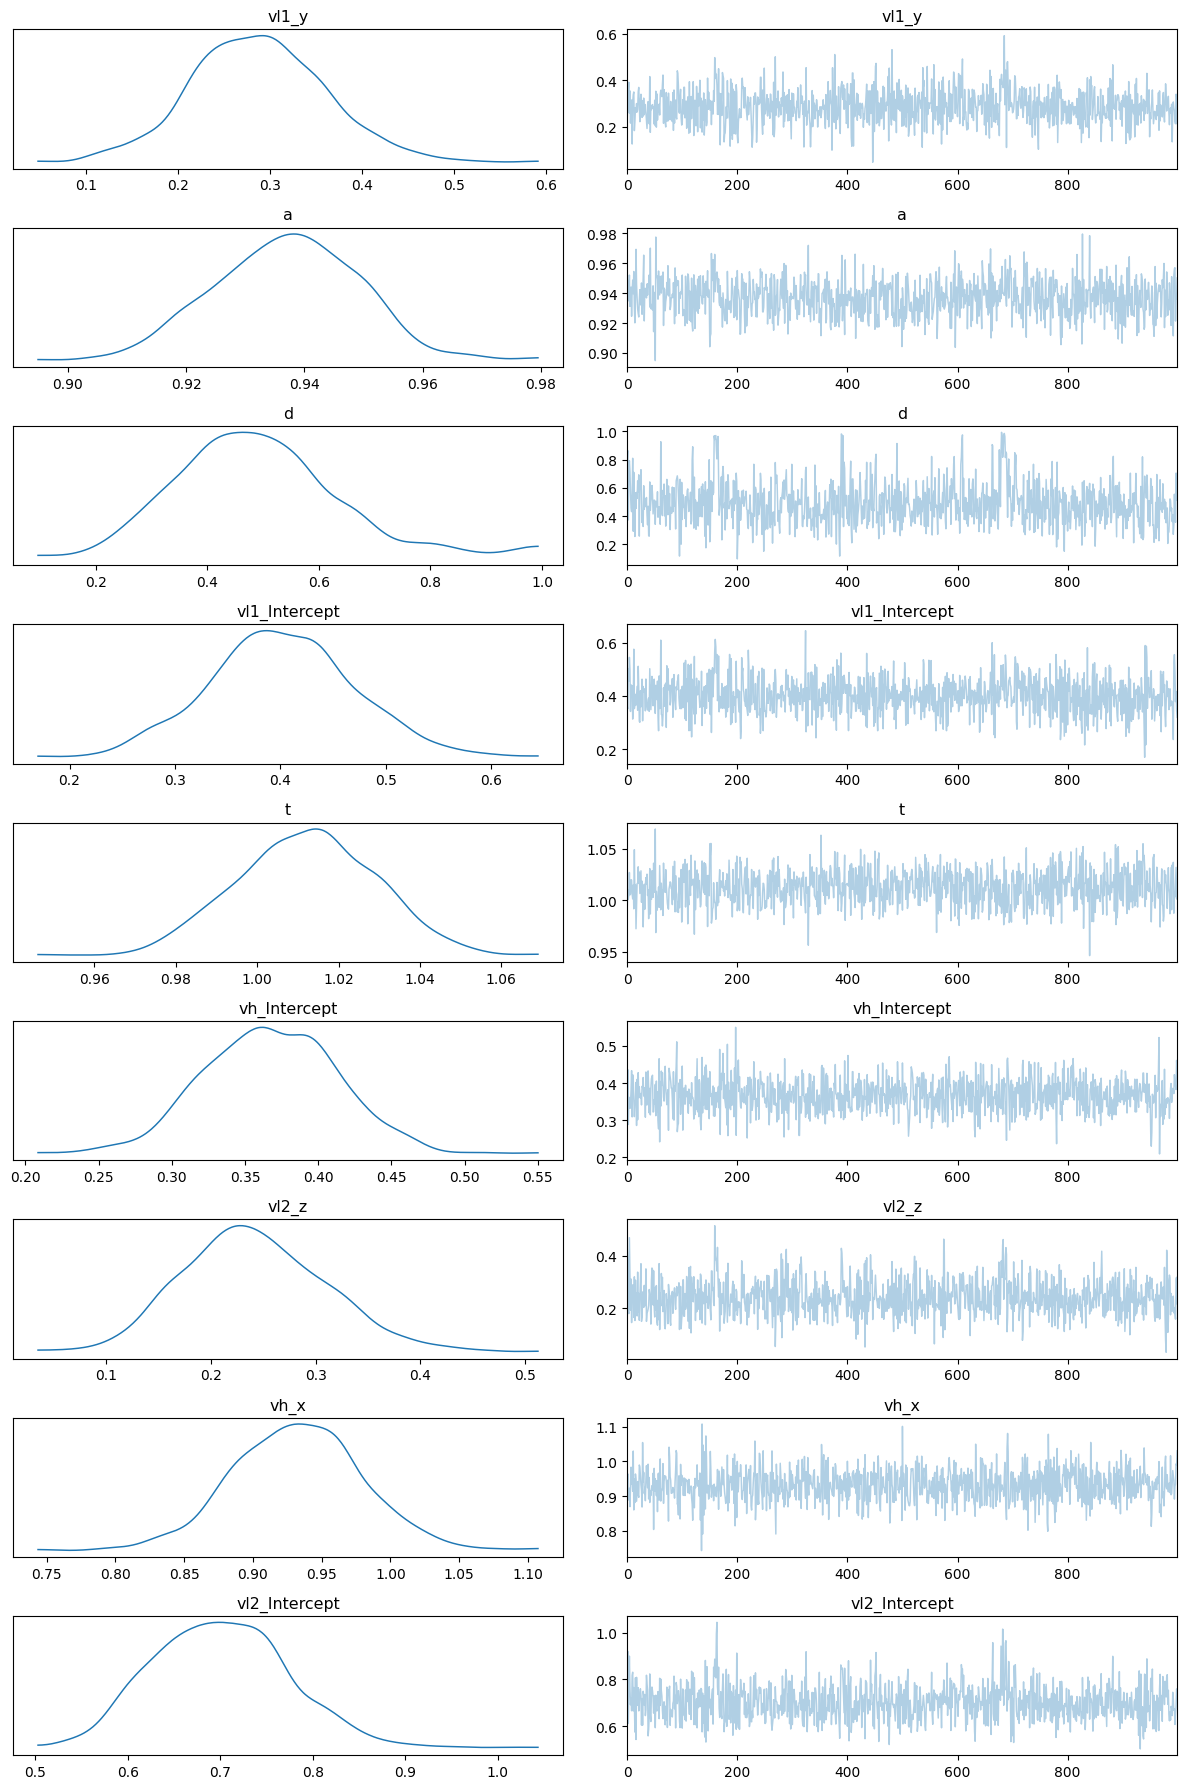

In [15]:
modelPipe.hssm_model.plot_trace()

In [8]:
output.plot_posterior_predictive(draws = 1)

AttributeError: 'InferenceData' object has no attribute 'plot_posterior_predictive'

In [6]:
modelPipe.posterior_predictive_copy(size = 1)

ValueError: These variables cannot be found in this dataset: ['vl2', 'rt,response_obs', 'vl1', 'vh']

In [36]:
modelPipe.plotting_dict['sim_output_list'][0]


,rt,response
0,17.275007,0.0
1,7.969346,1.0
2,4.607073,3.0
3,5.102442,1.0
4,4.951356,1.0
...,...,...
995,8.005955,0.0
996,6.184444,3.0
997,5.188075,1.0
998,4.267358,3.0


In [28]:
for i in range(4):
        
        param_full = np.repeat(np.array(param_array).reshape((1,input_dim)), dataset_size, axis = 0)
        reaction_times = np.linspace(0, 8, dataset_size).reshape((dataset_size,1))
        choices = np.repeat((np.array([i])), dataset_size).reshape((dataset_size,1))
        final_output = torch.from_numpy(np.concatenate((param_full, reaction_times, choices), axis = 1, dtype = np.float32)).to('cuda:0')
        network_output = network(final_output)
        likelihoods = np.exp(network_output.cpu())
        GT_array = dataset_lca[dataset_lca[:,1] == i][:,0]
        GT_array2 = dataset_lca2[dataset_lca2[:,1] == i][:,0]
        ax[i//2,i%2].plot(reaction_times, likelihoods)
        ax2[i//2,i%2].plot(reaction_times, likelihoods)
        ax2[i//2,i%2].set_ylim([0, 1])
    #% of that choice in the dataset
        gt_shape = GT_array.shape[0]
        gt_shape2 = GT_array2.shape[0]
        if gt_shape != 0:
            density_ratio = gt_shape /dataset_size
            density_ratio2 = gt_shape2 /dataset_size
            weights = np.repeat((density_ratio/(gt_shape )/bin_length), gt_shape )
            ax[i//2,i%2].hist(GT_array, bins = my_bins, density = False, weights = np.repeat((density_ratio/gt_shape/bin_length), gt_shape), histtype='step')  
            ax2[i//2,i%2].hist(GT_array, bins = my_bins, density = False, weights = np.repeat((density_ratio/gt_shape/bin_length), gt_shape), histtype='step')
            ax2[i//2,i%2].hist(GT_array2, bins = my_bins, density = False, weights = np.repeat((density_ratio2/gt_shape2/bin_length), gt_shape2), histtype='step') 
    
    plt.show()

dict_keys(['choice_ppd', 'choice_p_gt', 'sim_output_list', 'groundtruth_ppd'])

In [32]:
modelPipe.plotting_dict['sim_output_list'][0]

AttributeError: 'InferenceData' object has no attribute 'plotting_dict'

In [40]:
density_ratio_p = modelPipe.plotting_dict['choice_ppd']/1000
modelPipe.plotting_dict['choice_ppd']

array([[224.],
       [227.],
       [ 43.],
       [506.]])

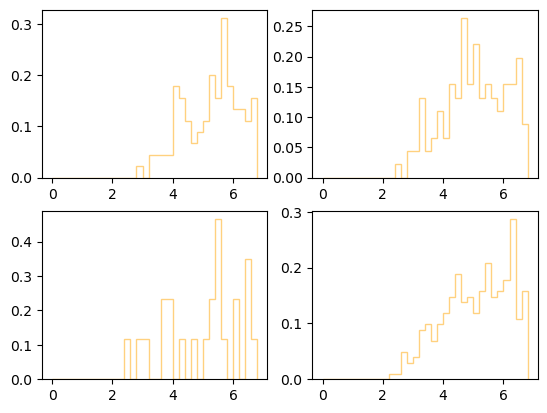

In [43]:
my_bins = np.arange(0,7,0.2) 
bin_length = np.abs((my_bins[1] - my_bins[0]))
for c in range (1): #Loop through chains
    fig,ax = plt.subplots(2, 2)
    for i in range(4): #Loop through choices
        ax[i//2,i%2].hist(modelPipe.plotting_dict['sim_output_list'][c][modelPipe.plotting_dict['sim_output_list'][c]['response'] == i]['rt'],
                            bins=my_bins, alpha = 0.5, color = 'orange', density = False,
                            weights = np.repeat(1/(modelPipe.plotting_dict['choice_ppd'][i][c]*bin_length), modelPipe.plotting_dict['choice_ppd'][i][c]), histtype = 'step')
        ax[i//2,i%2].hist(modelPipe.plotting_dict['groundtruth_ppd'][modelPipe.plotting_dict[groundtruth_ppd['response'] == i]['rt'],
    #                         bins=my_bins, alpha = 0.5, color = 'black', density = False,
    #                         weights=np.repeat((density_ratio_gt[i]/choice_p_gt[i]/bin_length), choice_p_gt[i]), histtype = 'step')
    #     ax[i//2,i%2].title.set_text('choice ' + str(i))
    #     ax[i//2,i%2].set_xlabel('reaction time (seconds)')
    #     ax[i//2,i%2].set_ylabel('density')
    # plt.tight_layout()
    # plt.legend(['posterior', 'ground truth'])

In [14]:
def posterior_predictive_copy(model, size):
        '''

        Inputs
        ------
        size: int
              the number of times of the dataset to call for posterior predictive. This is relevant because we are re-using regressors from the ground truth.
        '''
    
        #Reconstruct the regression targets by repeating them, note 
        # dataset_length = size
        mean_by_chain = self.sample_output.posterior.mean(dim='draw').drop_vars(['vl1', 'vl2','vh', 'rt,response_obs']).to_dataframe()
        vh_reconstructed = np.zeros((self.draws * size, self.chains))
        vl1_reconstructed = np.zeros((self.draws * size ,self.chains))
        vl2_reconstructed = np.zeros((self.draws * size ,self.chains))

        regX_repeated = np.repeat(self.regressor_groundtruth['regressor_x'], size)
        regY_repeated = np.repeat(self.regressor_groundtruth['regressor_y'], size)
        regZ_repeated = np.repeat(self.regressor_groundtruth['regressor_y'], size)
        df = self.sample_output.posterior.drop_vars(['rt,response_obs', 'vh', 'vl1', 'vl2']).to_dataframe() #process the trace object
        #Loop through each chain to recreate regression targets based on mean by chains
        for c in range(self.chains):
            vh_reconstructed[:,c] = df['vh_Intercept'][c] + df['vh_x'][c] * regX_repeated
            vl1_reconstructed[:,c] = df['vl1_Intercept'][c] + df['vl1_y'][c] * regY_repeated
            vl2_reconstructed[:,c] = df['vl2_Intercept'][c] + df['vl2_z'][c] * regZ_repeated

        sim_output_list = [] #list of dictionaries
        
        #Loop through each chain to recreate the vector, then simulate with ssms to get posterior predictives.
        for c in range(self.chains):
            copydict = deepcopy(self.param_dict)
            for k in list(df.keys()): #If the param of the idata table matches the one in dict, we update it with the trace
                if k in copydict:
                    copydict[k] = df[k][c].to_numpy()
            copydict.update({'vh': vh_reconstructed[:,c], 'vl1': vl1_reconstructed[:,c], 'vl2': vl2_reconstructed}) #Then we update it with the regression target
            #Simulate and organise into rt, choices
            obs_ppd = simulator(copydict, model= self.model_name, n_samples=1, smooth_unif = False)
            dataset_obs = pd.DataFrame(
                            np.column_stack((obs_ppd["rts"][:, 0], obs_ppd["choices"][:, 0])),
                            columns=["rt", "response"])
            sim_output_list.append(dataset_obs)

            

        #PLOTTING
        
        #calculate density of choices for plot
        groundtruth_ppd = self.dataset_generator(fixed_coh = self.fixed_coh, dataset_size = self.draws * size)
        choice_p_ppd = np.zeros((4,self.chains))
        choice_p_gt = np.zeros(4)

        for i in range(4):
            choice_p_gt[i] = int(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            print(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'].shape[0])
            for c in range(self.chains):
                choice_p_ppd[i][c] = int(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'].shape[0])
        density_ratio_ppd = choice_p_ppd/size
        density_ratio_gt = choice_p_gt/size
        #plot


        
        my_bins = np.arange(0,7,0.2) 
        bin_length = np.abs((my_bins[1] - my_bins[0]))
        
        plotting_dict = {'choice_ppd': choice_p_ppd,
                         'choice_p_gt': choice_p_gt,
                         'sim_output_list': sim_output_list,
                         'groundtruth_ppd': groundtruth_ppd}

        for c in range (self.chains): #Loop through chains
            fig,ax = plt.subplots(2, 2)
            for i in range(4): #Loop through choices
                ax[i//2,i%2].hist(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'],
                                    bins=my_bins, alpha = 0.5, color = 'orange', density = False,
                                    weights = np.repeat((density_ratio_ppd[i][c]/choice_p_ppd[i][c]/bin_length), choice_p_ppd[i][c]), histtype = 'step')
                                    #choice_p_ppd[i][c]
                ax[i//2,i%2].hist(groundtruth_ppd[groundtruth_ppd['response'] == i]['rt'],
                                    bins=my_bins, alpha = 0.5, color = 'black', density = False,
                                    weights=np.repeat((density_ratio_gt[i]/choice_p_gt[i]/bin_length), choice_p_gt[i]), histtype = 'step')
                ax[i//2,i%2].title.set_text('choice ' + str(i))
                ax[i//2,i%2].set_xlabel('reaction time (seconds)')
                ax[i//2,i%2].set_ylabel('density')
            plt.tight_layout()
            plt.legend(['posterior', 'ground truth'])
        self.plotting_dict = plotting_dict
        
        return plotting_dict

In [22]:
modelPipe.hssm_model.traces.posterior_predictive['rt,response'][0,:,:]

<xarray.DataArray 'rt,response' (draw: 2, rt,response_obs: 1000,
                                 rt,response_dim: 2)> Size: 32kB
array([[[3.10684133, 2.        ],
        [3.27222347, 2.        ],
        [3.18098521, 2.        ],
        ...,
        [3.17045808, 0.        ],
        [3.5632565 , 2.        ],
        [3.44324422, 2.        ]],

       [[3.37699914, 2.        ],
        [2.79152298, 2.        ],
        [3.55609512, 3.        ],
        ...,
        [3.76263094, 2.        ],
        [3.1718874 , 2.        ],
        [3.3257215 , 2.        ]]])
Coordinates:
    chain            int64 8B 0
  * draw             (draw) int64 16B 684 623
  * rt,response_obs  (rt,response_obs) int64 8kB 0 1 2 3 4 ... 996 997 998 999
  * rt,response_dim  (rt,response_dim) int64 16B 0 1

In [19]:
rt_resp = modelPipe.hssm_model.traces.posterior_predictive['rt,response'].to_numpy()

In [26]:
rt_resp[0,1,:,:]

array([[3.37699914, 2.        ],
       [2.79152298, 2.        ],
       [3.55609512, 3.        ],
       ...,
       [3.76263094, 2.        ],
       [3.1718874 , 2.        ],
       [3.3257215 , 2.        ]])

In [4]:
#Posterior predictive
modelPipe.hssm_model.sample_posterior_predictive(n_samples = 2)

In [10]:
rt_response = output.posterior_predictive['rt,response'][0].to_numpy()

In [15]:
df_list = []
for i in range(rt_response.shape[0]):
    data['rt'] = rt_response[0][:,0]
    data['response'] = rt_response[0][:,1]
    data_big = data.copy(deep = True)
    df_list.append(data_big)
    
full_pd = pd.concat(df_list)

In [52]:
output.posterior.drop_vars(['rt,response_obs', 'vl1']).to_dataframe() 

a         t  vh_Intercept      vh_x  \
chain draw rt,response_obs                                               
0     0    0                1.913892  0.504006      0.625799  0.553349   
           1                1.913892  0.504006      0.625799  0.553349   
           2                1.913892  0.504006      0.625799  0.553349   
           3                1.913892  0.504006      0.625799  0.553349   
           4                1.913892  0.504006      0.625799  0.553349   
...                              ...       ...           ...       ...   
3     999  995              1.880829  0.538305      0.571988  0.542438   
           996              1.880829  0.538305      0.571988  0.542438   
           997              1.880829  0.538305      0.571988  0.542438   
           998              1.880829  0.538305      0.571988  0.542438   
           999              1.880829  0.538305      0.571988  0.542438   

                            vl1_Intercept     vl1_y       vl2        vh  
chain draw rt,response_obs                                               
0     0    0                     1.036184  0.935023  1.255572  1.179148  
           1                     1.036184  0.935023  1.255572  1.179148  
           2                     1.036184  0.935023  1.255572  1.179148  
           3                     1.036184  0.935023  1.255572  1.179148  
           4                     1.036184  0.935023  1.255572  1.179148  
...                                   ...       ...       ...       ...  
3     999  995                   0.862305  0.817053  1.232349  0.029550  
           996                   0.862305  0.817053  1.232349  0.029550  
           997                   0.862305  0.817053  1.232349  1.114426  
           998                   0.862305  0.817053  1.232349  0.029550  
           999                   0.862305  0.817053  1.232349  1.114426  

[4000000 rows x 8 columns]

0.23076923076923078
0.3269230769230769
0.5
0.4423076923076923
0.7307692307692307
0.17307692307692307
0.09615384615384616
0.21153846153846154
0.2692307692307692
0.3269230769230769
0.25
0.3541666666666667
0.3333333333333333
0.6041666666666666
0.6666666666666666
0.0625
0.0625
0.08333333333333333
0.1875
0.0625
0.020833333333333332
0.0
0.0
0.0
0.0
0.020833333333333332
0.0
0.0
0.0
0.020833333333333332
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.294
0.0


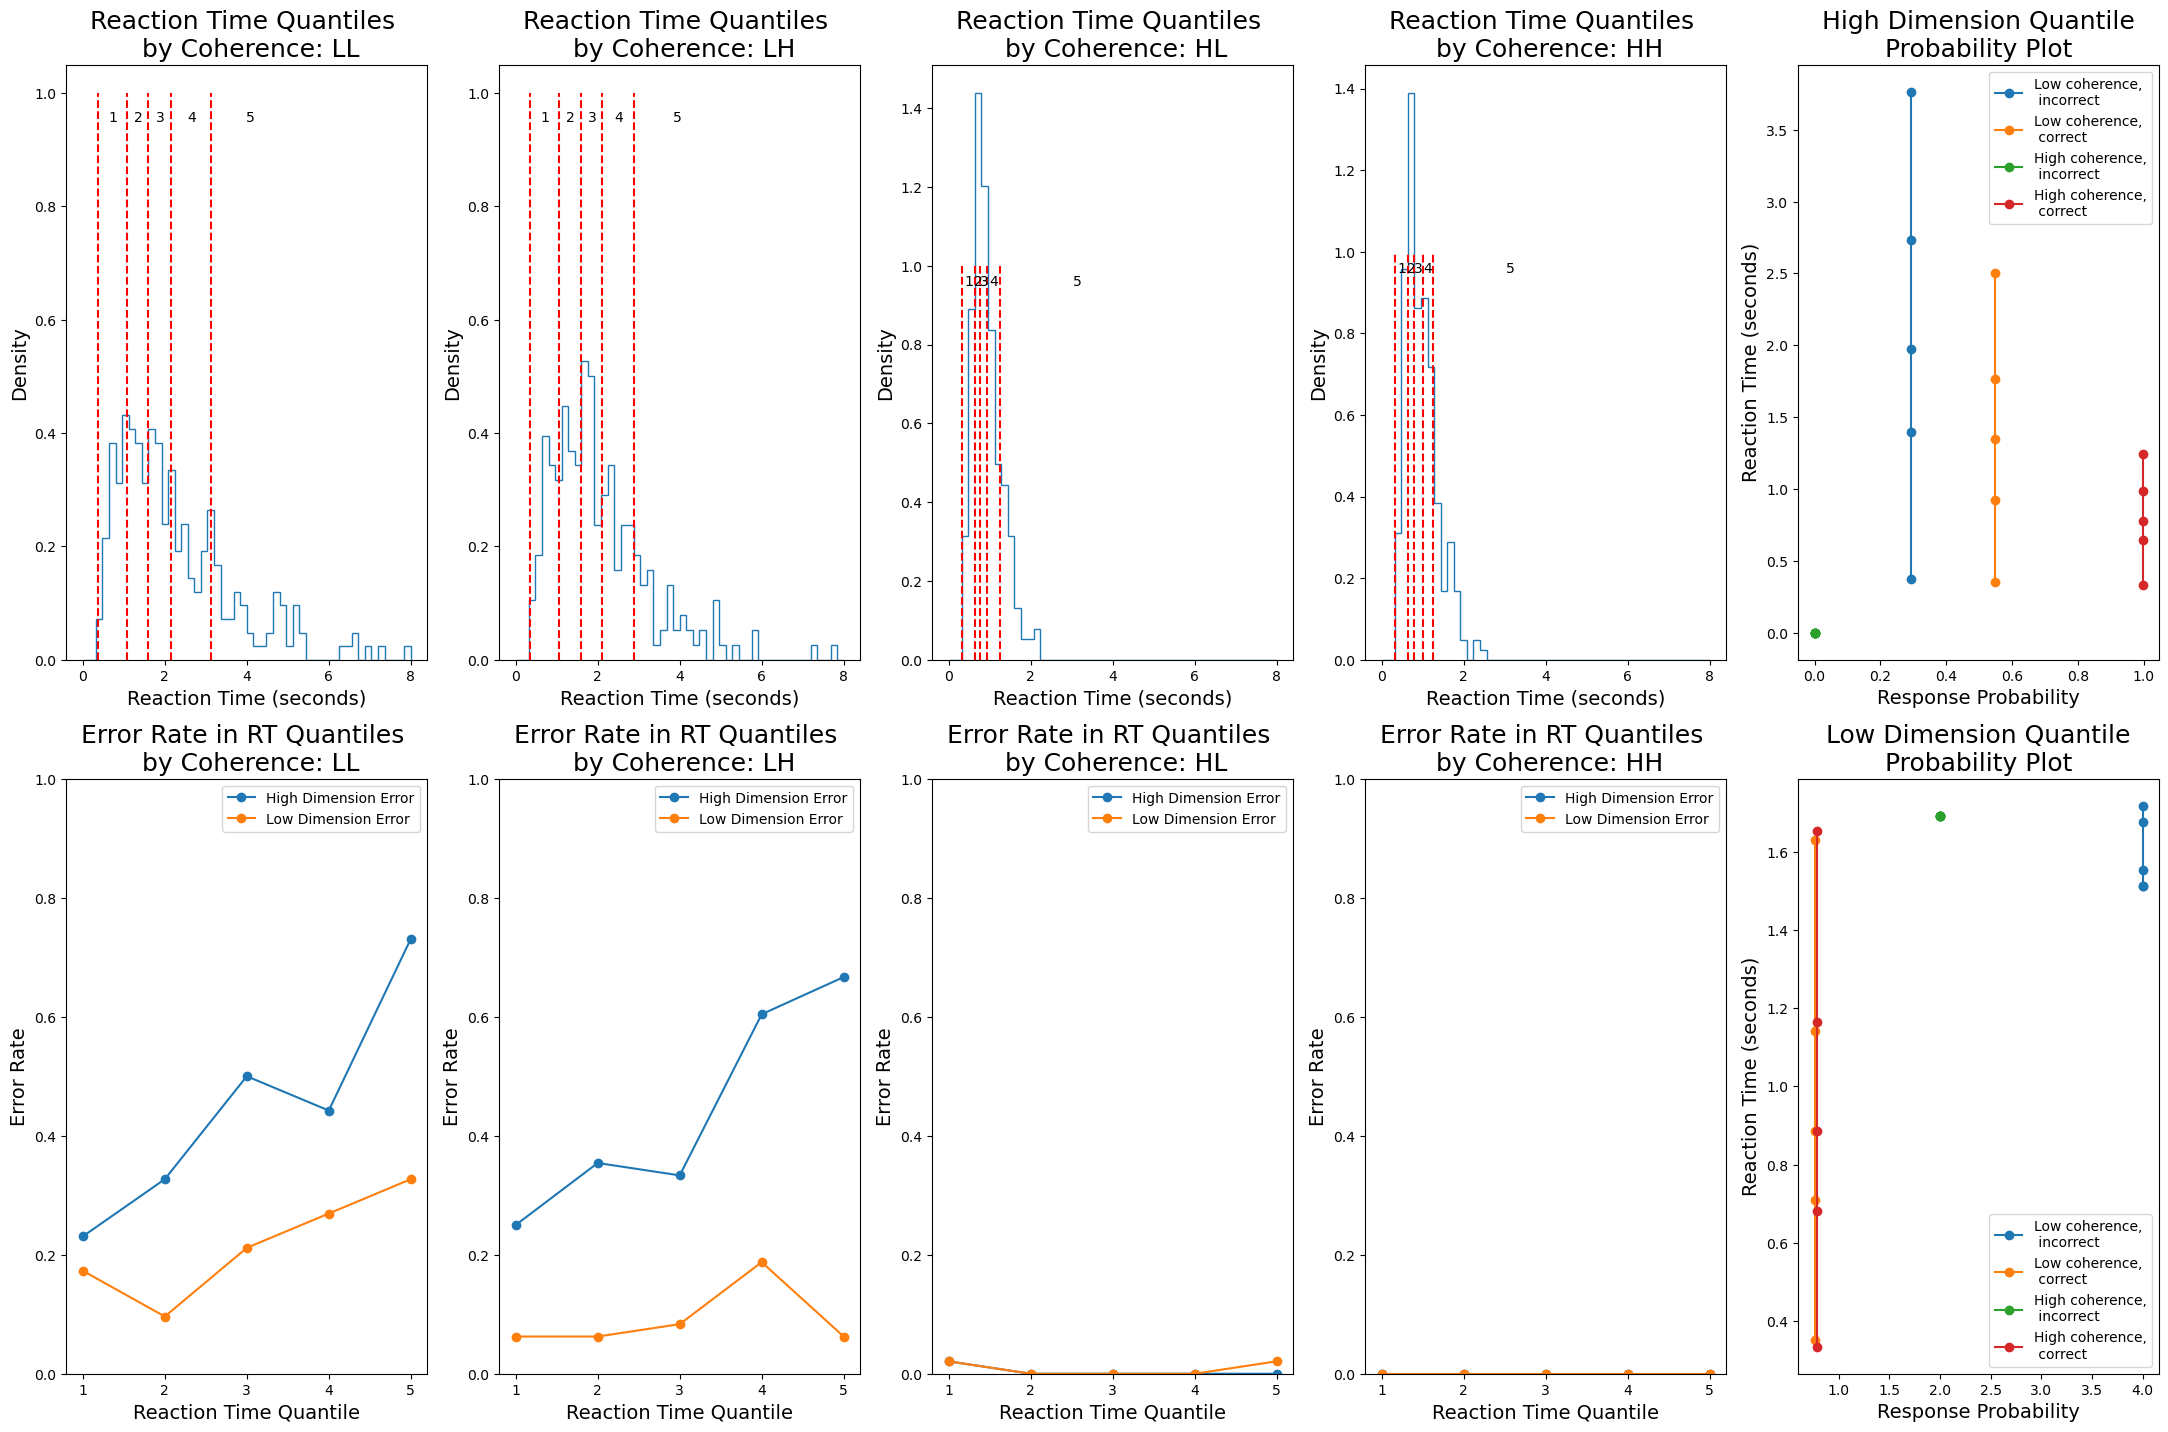

In [18]:
#Edit into form that the code wants
full_pd = full_pd.rename({'rt': 'rxtime',
                    'subj_idx': 'subj',
                    'x': 'highDimCoh',
                    'y': 'lowDimCoh'}, axis = 'columns')

plt.figure(figsize=(27,17))
# all_plots(full_pd)
all_plots(full_pd)

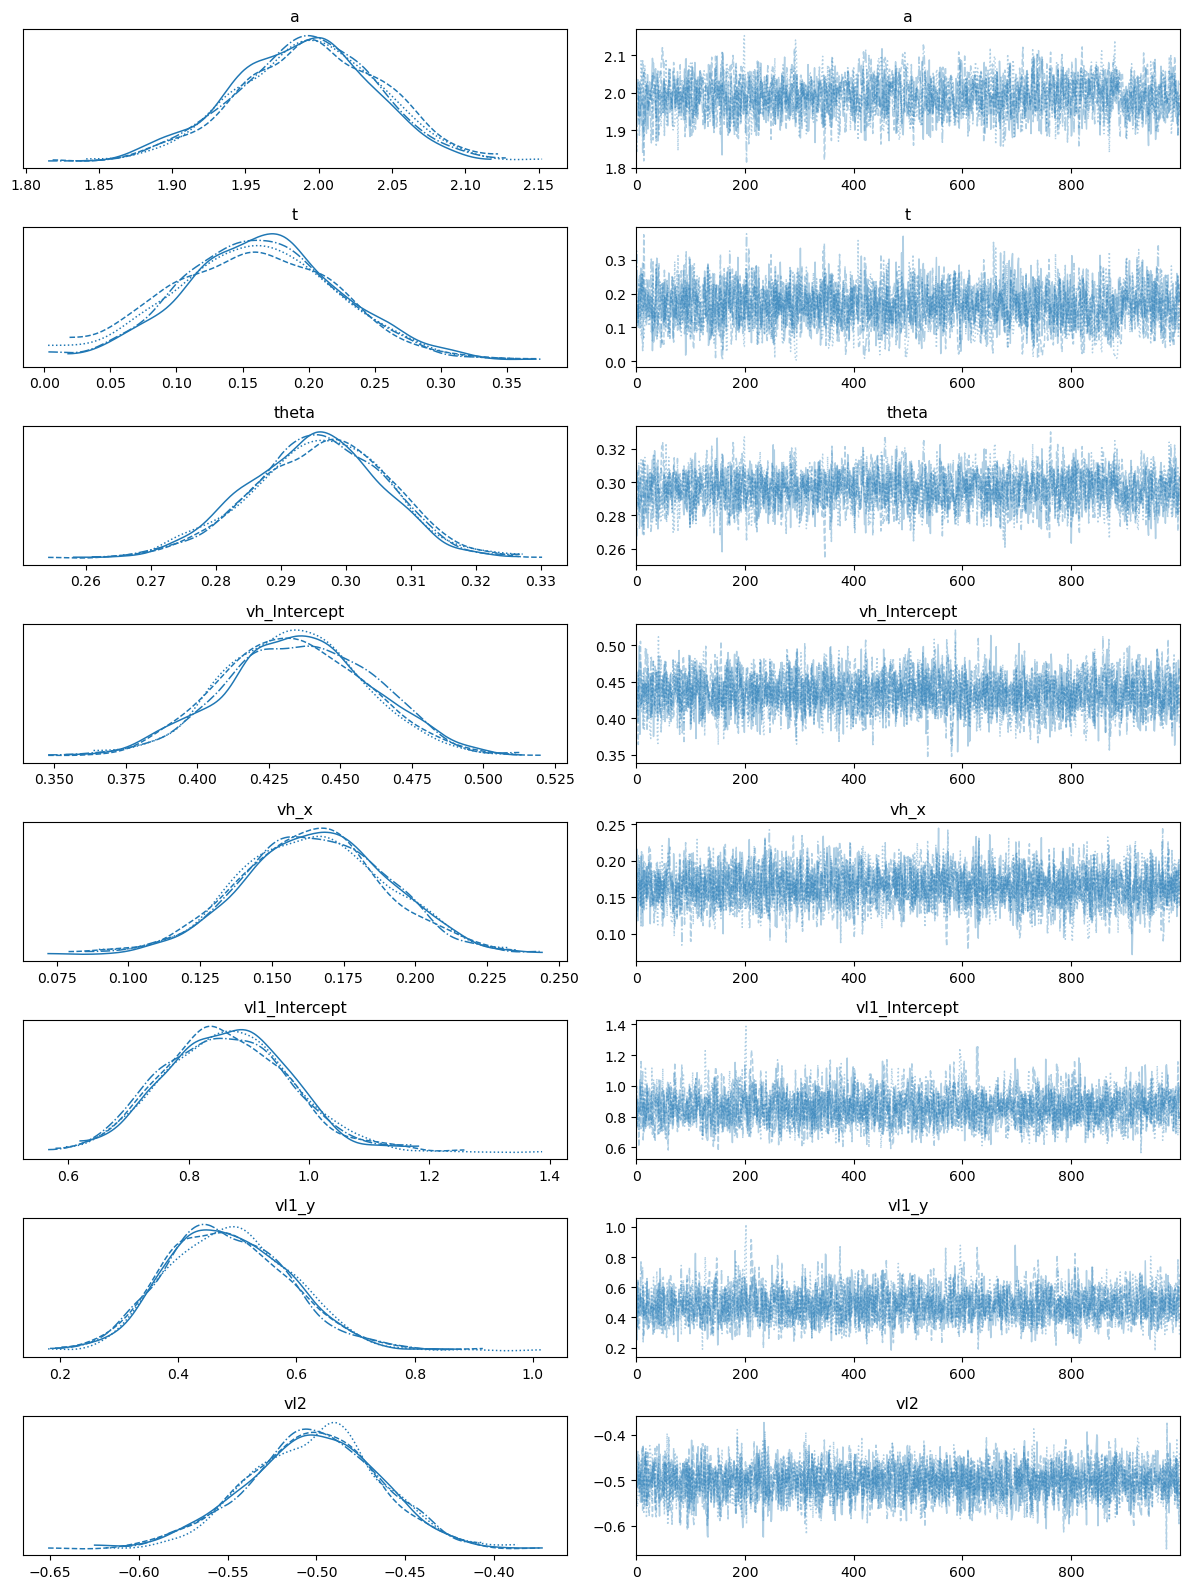

In [6]:
modelPipe.hssm_model.plot_trace()

In [9]:
my_idata = output
my_idata.posterior = my_idata.posterior.isel(draw=np.arange(10))

In [10]:
modelPipe.hssm_model.sample_posterior_predictive(idata = my_idata)

In [25]:
output.posterior

<xarray.Dataset> Size: 651kB
Dimensions:           (chain: 4, draw: 10, rt,response_obs: 1000)
Coordinates:
  * chain             (chain) int64 32B 0 1 2 3
  * draw              (draw) int64 80B 0 1 2 3 4 5 6 7 8 9
  * rt,response_obs   (rt,response_obs) int64 8kB 0 1 2 3 4 ... 996 997 998 999
Data variables:
    a                 (chain, draw) float64 320B 1.969 2.02 ... 1.967 1.941
    t                 (chain, draw) float64 320B 0.2146 0.1502 ... 0.175 0.2571
    theta             (chain, draw) float64 320B 0.2971 0.303 ... 0.2912 0.292
    vh_Intercept      (chain, draw) float64 320B 0.4369 0.4344 ... 0.4147 0.4278
    vh_x              (chain, draw) float64 320B 0.1396 0.1842 ... 0.1749 0.1375
    vl1_Intercept     (chain, draw) float64 320B 0.9655 0.7266 ... 1.025 1.159
    vl1_y             (chain, draw) float64 320B 0.5846 0.3797 ... 0.674 0.7779
    vl2               (chain, draw) float64 320B -0.494 -0.5112 ... -0.4842
    rt,response_mean  (chain, draw, rt,response_obs) float64 320kB 0.5765 ......
    vl1               (chain, draw, rt,response_obs) float64 320kB 0.3809 ......
Attributes:
    created_at:                  2024-07-07T02:09:21.691440+00:00
    arviz_version:               0.18.0
    modeling_interface:          bambi
    modeling_interface_version:  0.13.0

In [23]:
my_idata.posterior_predictive

<xarray.Dataset> Size: 648kB
Dimensions:          (chain: 4, draw: 10, rt,response_obs: 1000,
                      rt,response_dim: 2)
Coordinates:
  * chain            (chain) int64 32B 0 1 2 3
  * draw             (draw) int64 80B 0 1 2 3 4 5 6 7 8 9
  * rt,response_obs  (rt,response_obs) int64 8kB 0 1 2 3 4 ... 996 997 998 999
  * rt,response_dim  (rt,response_dim) int64 16B 0 1
Data variables:
    rt,response      (chain, draw, rt,response_obs, rt,response_dim) float64 640kB ...
Attributes:
    modeling_interface:          bambi
    modeling_interface_version:  0.13.0

In [ ]:
mcmc_output = modelPipe.sample(sampler='mcmc')

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [vl2, a, vh_Intercept, vh_x, vl1_Intercept, vl1_y]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 183 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [ ]:
modelPipe.save(path = '/users/avo2/data/avo2/LANminimal/',
               file_name = 'test')

AttributeError: 'ModelPipeline' object has no attribute 'plotting_dict'

In [18]:
modelPipe.posterior_predictive_copy(1000)

KeyboardInterrupt: 

In [29]:
short = output.posterior.drop_vars(['vl1', 'rt,response_mean'])
groundTruth = modelPipe.show_ground_truth()
res = [i for i in short.data_vars] 
ref_val_list = []
for key in res:
    try:
        if type(groundTruth[key] == tuple): #if it is a tuple then the parameter was not frozen, so the pmean is [1]
            ref_val_list.append(groundTruth[key][0])
        else:
                ref_val_list.append(groundTruth[key])
    except KeyError:
        pass
    

In [6]:
res

['a', 't', 'vh_Intercept', 'vh_x', 'vl1_Intercept', 'vl1_y', 'vl2', 'vh']

In [30]:
short

<xarray.Dataset> Size: 11kB
Dimensions:          (chain: 4, draw: 10, rt,response_obs: 1000)
Coordinates:
  * chain            (chain) int64 32B 0 1 2 3
  * draw             (draw) int64 80B 0 1 2 3 4 5 6 7 8 9
  * rt,response_obs  (rt,response_obs) int64 8kB 0 1 2 3 4 ... 996 997 998 999
Data variables:
    a                (chain, draw) float64 320B 1.969 2.02 2.019 ... 1.967 1.941
    t                (chain, draw) float64 320B 0.2146 0.1502 ... 0.175 0.2571
    theta            (chain, draw) float64 320B 0.2971 0.303 ... 0.2912 0.292
    vh_Intercept     (chain, draw) float64 320B 0.4369 0.4344 ... 0.4147 0.4278
    vh_x             (chain, draw) float64 320B 0.1396 0.1842 ... 0.1749 0.1375
    vl1_Intercept    (chain, draw) float64 320B 0.9655 0.7266 ... 1.025 1.159
    vl1_y            (chain, draw) float64 320B 0.5846 0.3797 ... 0.674 0.7779
    vl2              (chain, draw) float64 320B -0.494 -0.5112 ... -0.4842
Attributes:
    created_at:                  2024-07-07T02:09:21.691440+00:00
    arviz_version:               0.18.0
    modeling_interface:          bambi
    modeling_interface_version:  0.13.0

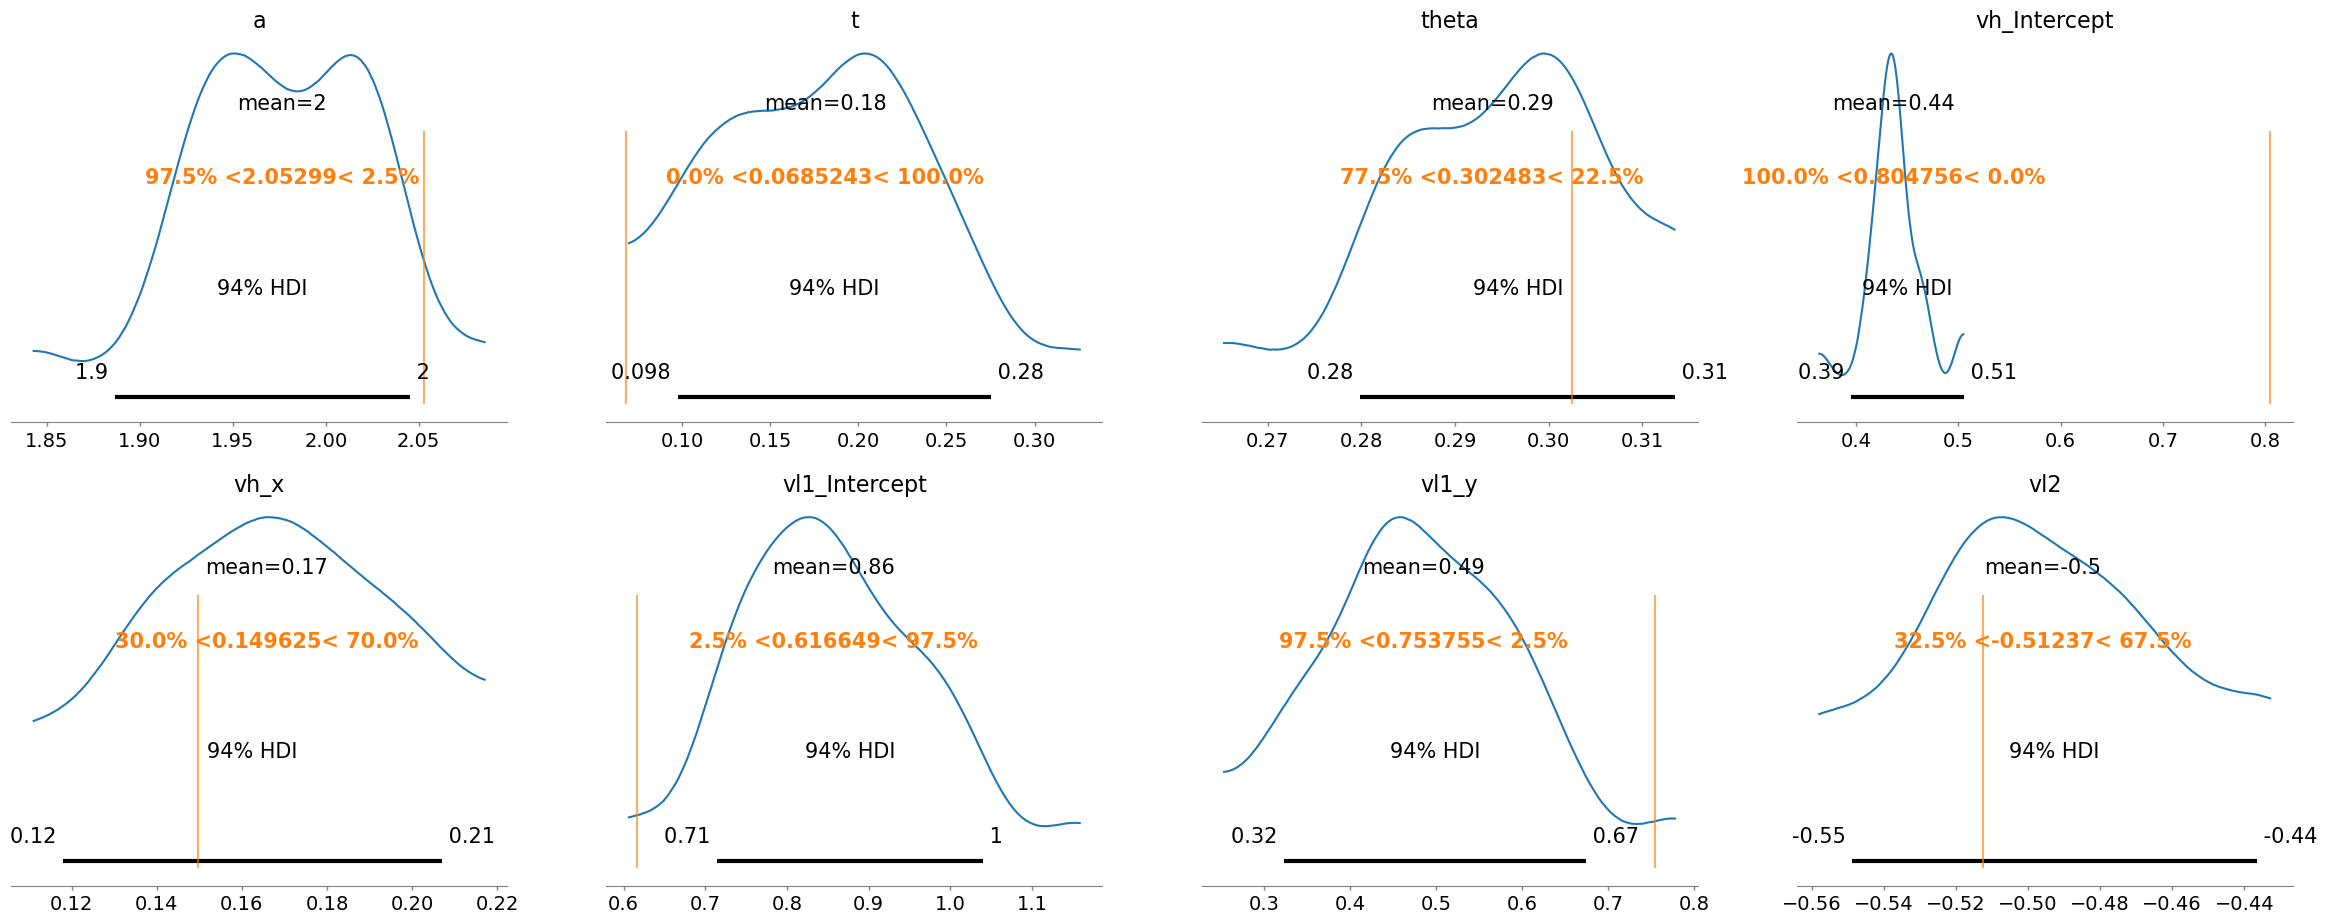

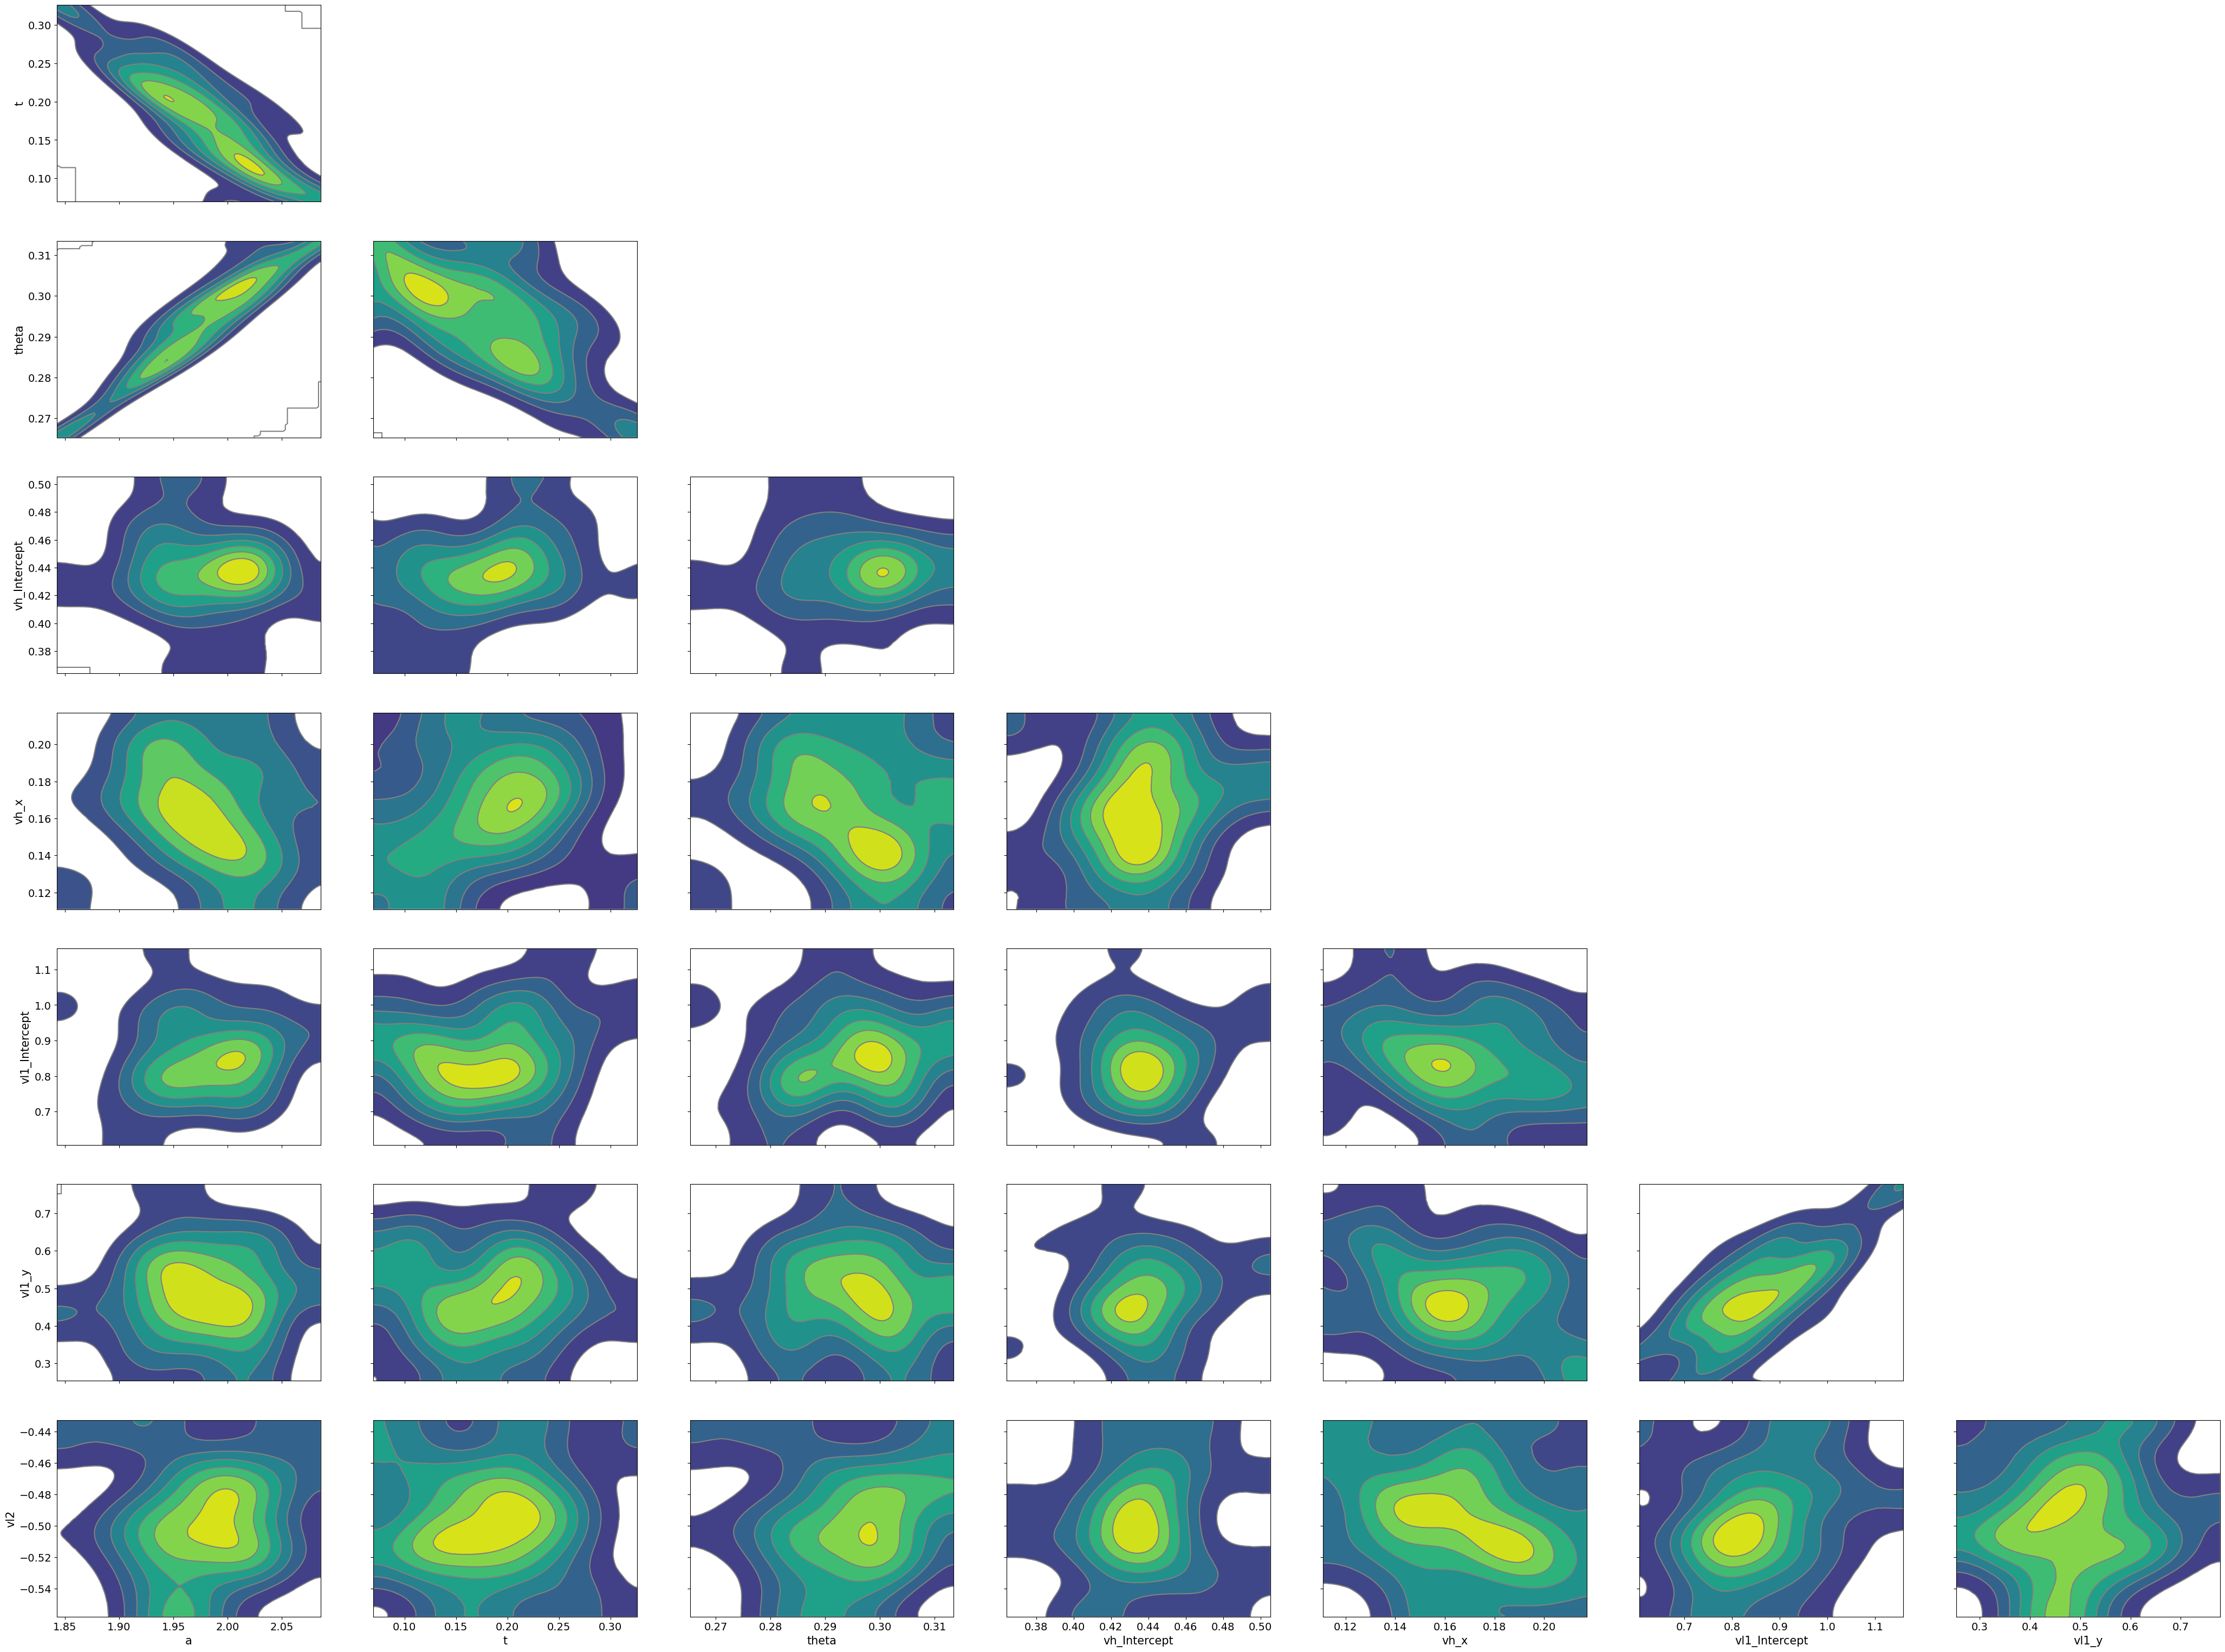

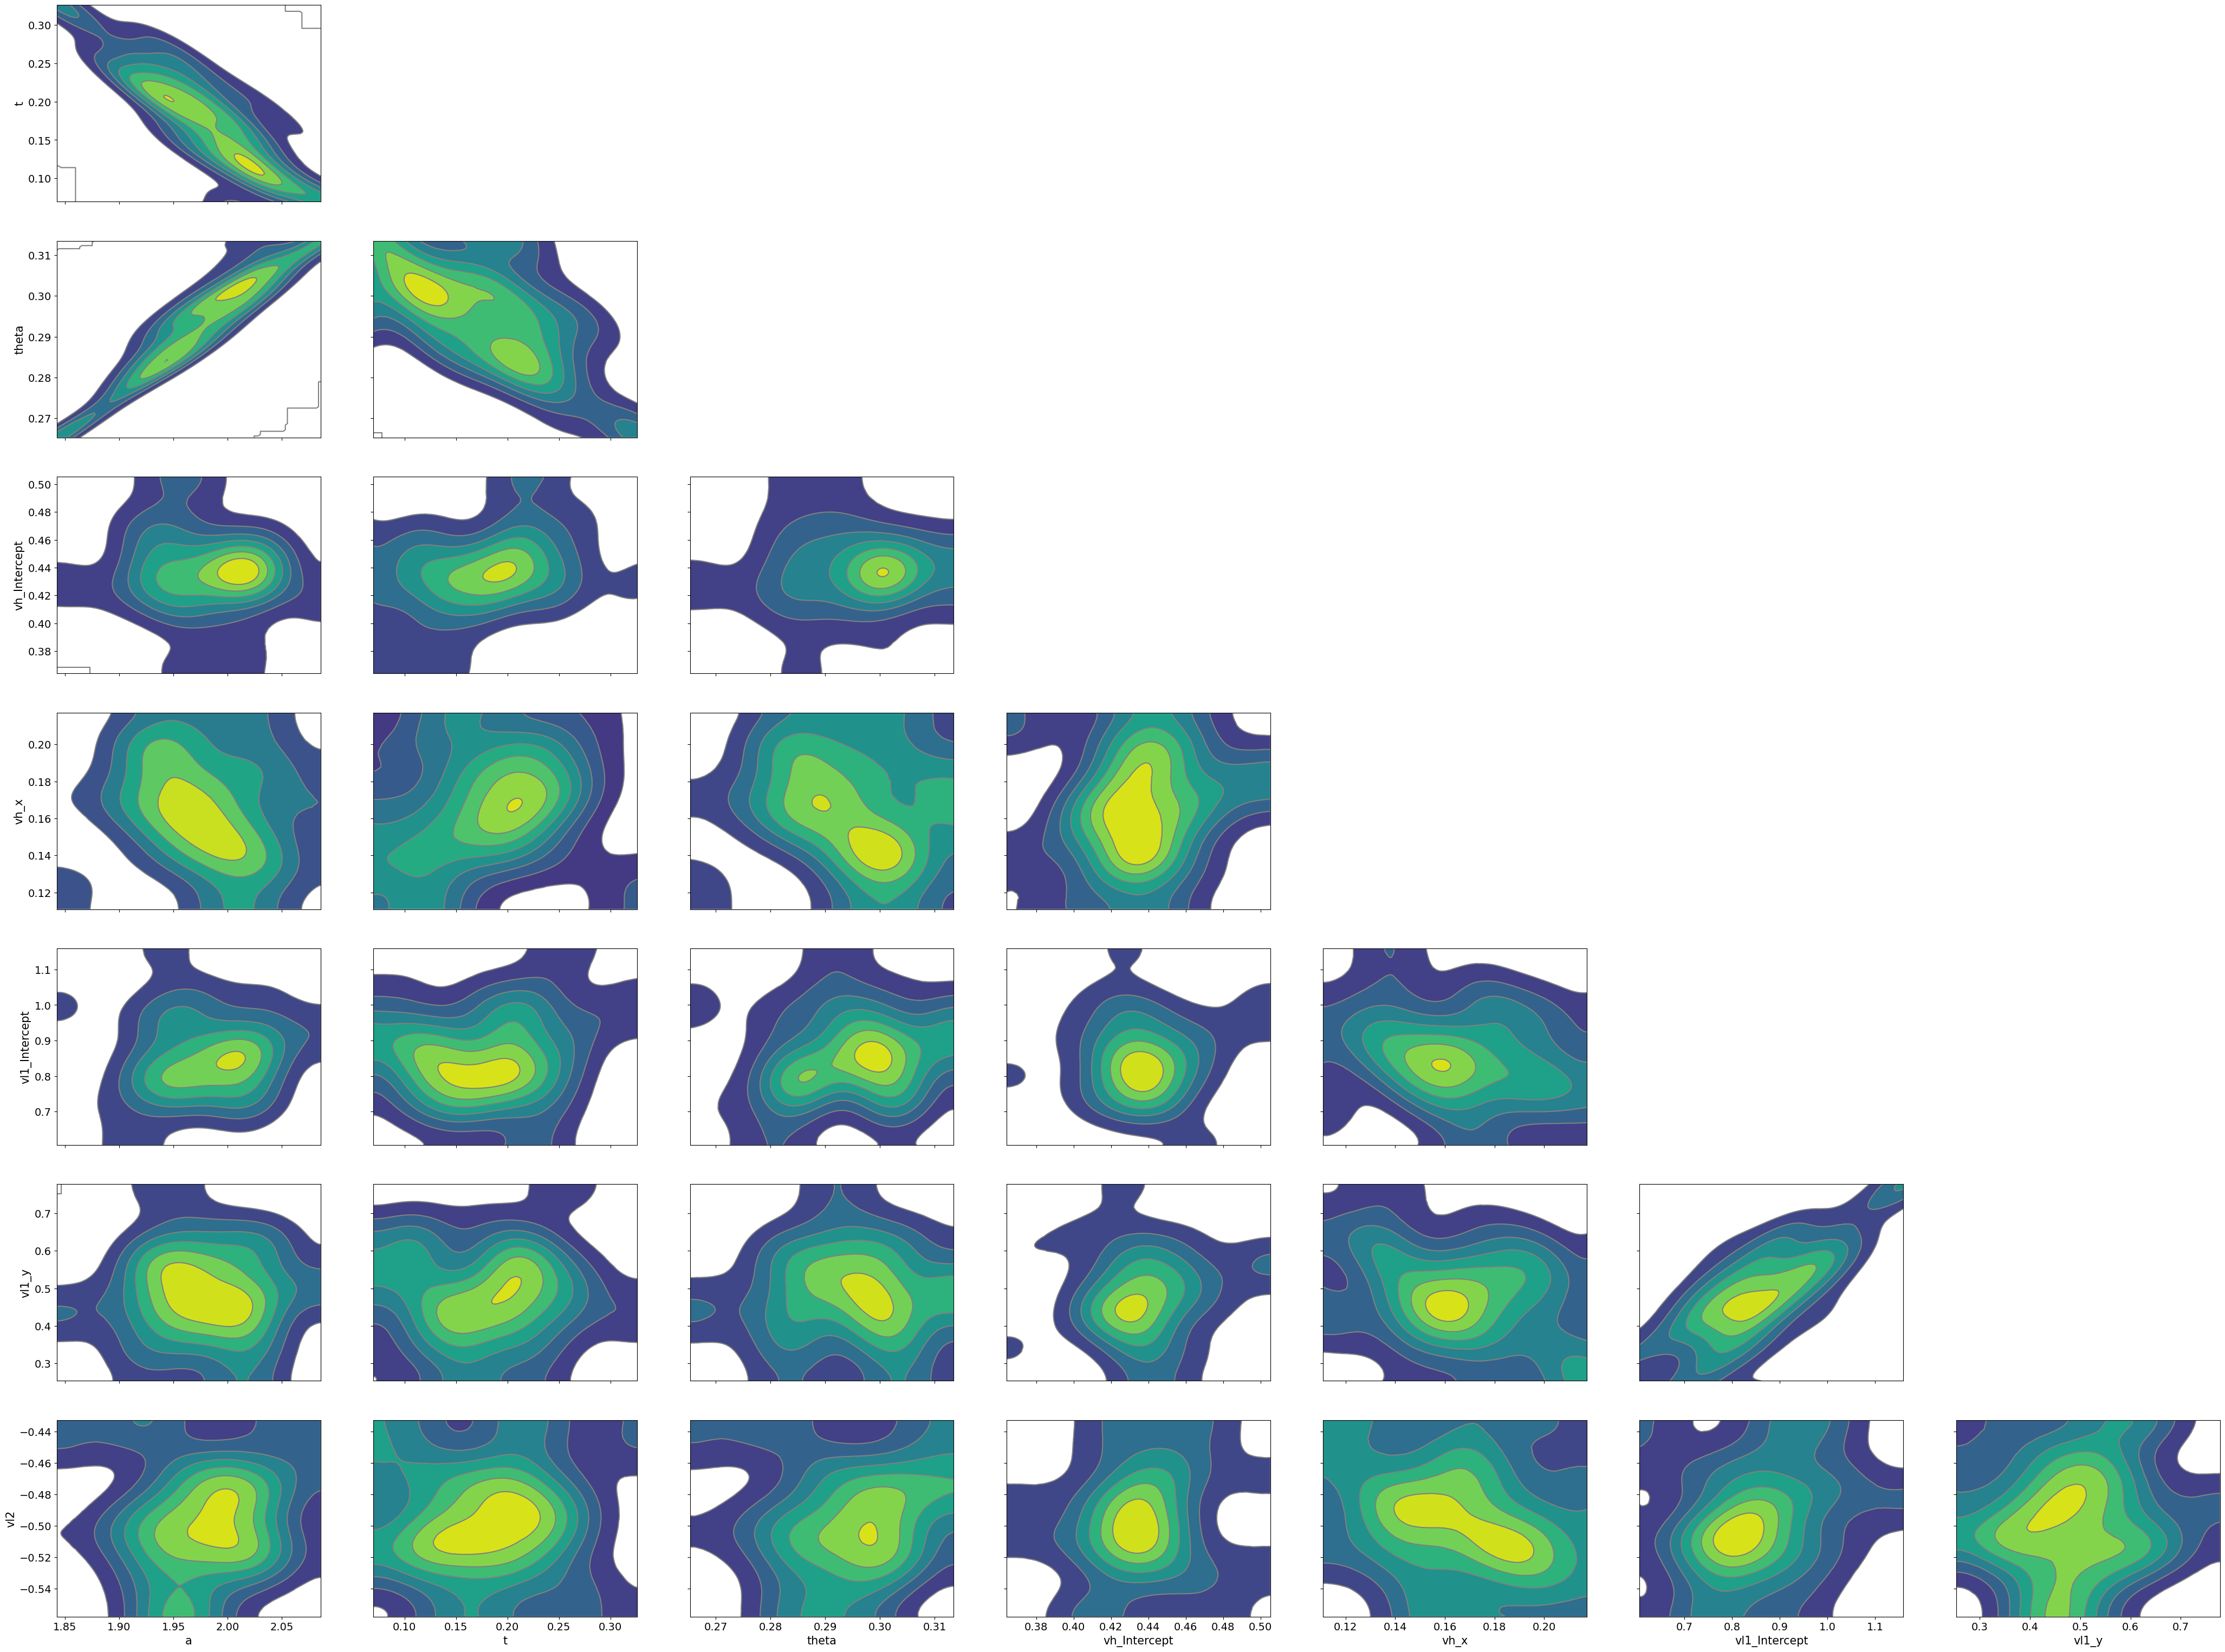

In [31]:
import arviz as az 
# lines = (('vl1_y',{'vl1_y': 0}, [0.4]),)
az.plot_posterior(short, ref_val = ref_val_list)
az.plot_pair(short, kind = 'kde')
axes = az.plot_pair(short, kind = 'kde')
fig = axes.ravel()[0].figure
fig.savefig('pair')

In [13]:
modelPipe.show_ground_truth()

{'vl2': (0.4085248539497961, 0.49312297122621807),
 'a': (1.6902189804972074, 1.7127222714341186),
 't': (1.05874306798411, 0.9636505609898347),
 'vh_Intercept': (0.08704763481496924, 0.036027475194430704),
 'vl1_Intercept': (0.9592682243936487, 0.9138617999223545),
 'vh_x': (0.8834371754055703, 0.8052535119883645),
 'vl1_y': (0.053635830958200015, 0.05636601822096421)}

In [ ]:
from arviz.plots.plot_utils import xarray_var_iter

ImportError: cannot import name 'xarray_var_iter' from 'arviz.plots.plot_utils' (/users/avo2/miniconda3/envs/hssm_sbi5/lib/python3.10/site-packages/arviz/plots/plot_utils.py)

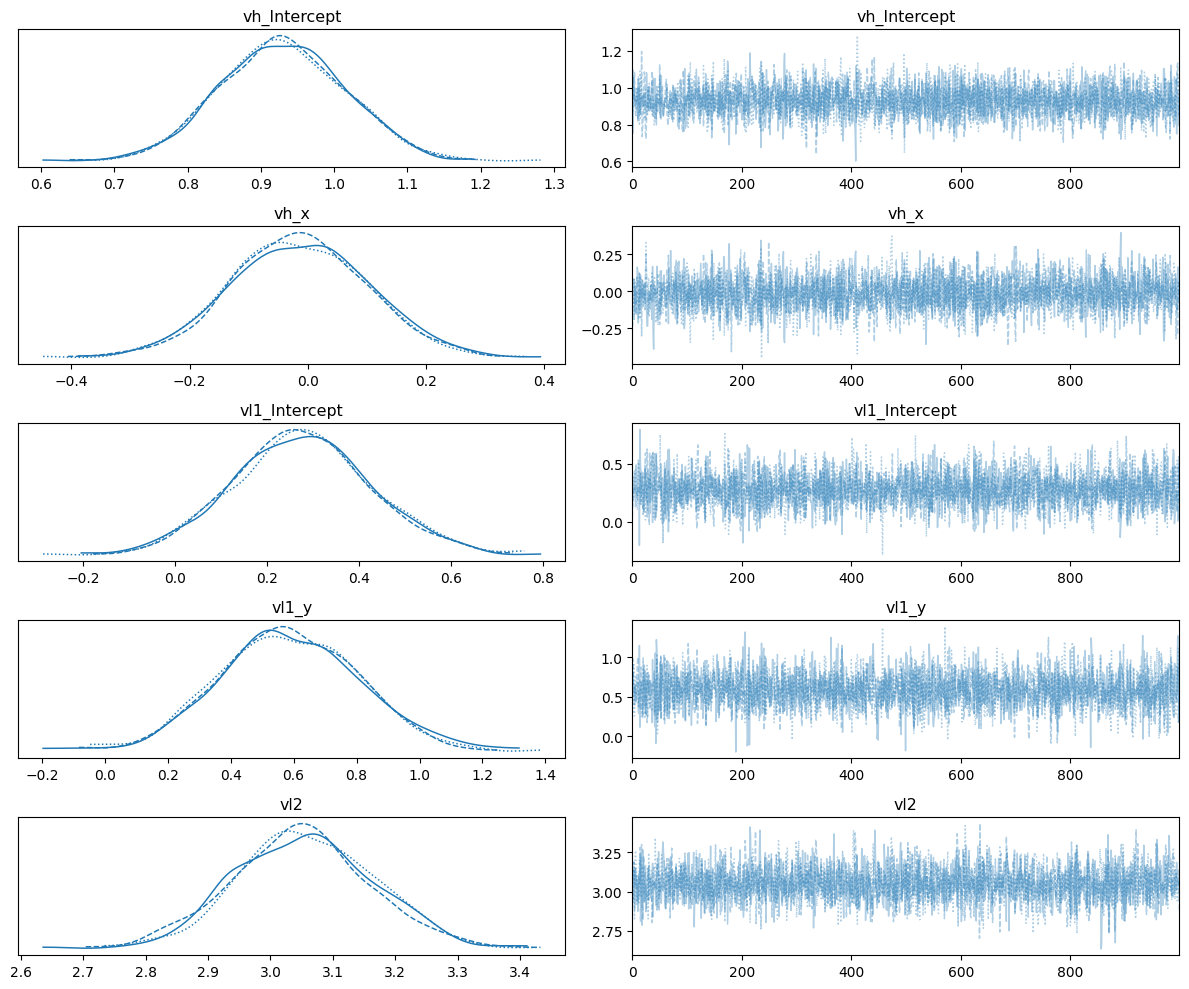

In [ ]:
import arviz as az

az.plot_trace(output,var_names=['~vl1'])
plt.tight_layout()




In [ ]:
modelPipe.show_ground_truth()

({'vl2': 1.2005744912237777,
  'a': 1.4552668955826475,
  'd': 0.9723772268173517,
  't': 0.9013709445841991,
  'vh_Intercept': 0.6507261238678457,
  'vl1_Intercept': 0.1175594165169036,
  'covar_x': 0.2851342907385426,
  'covar_y': 0.4915871849002147},
 {'vh_Intercept': 0.4764215810937093,
  'vh_x': 0.18174670998024112,
  'vl1_Intercept': 0.18599773723760163,
  'vl1_y': 0.3907518161992371,
  'vl2': 3.004149893031223,
  'a': 1.6909932756095174,
  'vl1': 0.19752015973032078})

In [ ]:
param_dict = modelPipe.param_dict
regressor_groundtruth = modelPipe.regressor_groundtruth
# modelPipe.regressor_groundtruth['covar_x'].type
groundtruthDict = {}
for i in param_dict.keys():
    if isinstance(param_dict[i], float):
        groundtruthDict[i] = param_dict[i]

for i in regressor_groundtruth.keys():
    if isinstance(regressor_groundtruth[i], float):
        groundtruthDict[i] = regressor_groundtruth[i]



In [ ]:
groundtruthDict

{'vl2': 3.178674070986407,
 'a': 0.9195378146152777,
 't': 1.728790897131219,
 'ivh': 0.5158684049706557,
 'ivl1': 0.928924256673433,
 'covar_x': 0.015019133939917162,
 'covar_y': 0.2969699629964183}

In [ ]:
import math
def posterior_predictive(output, model, chains, draws, dims):

    #Reconstruct the regression targets
    mean_by_chain = output.posterior.mean(dim='draw').to_dataframe()
    # print(mean_by_chain)
    vh_reconstructed = np.zeros((draws, chains))
    vl1_reconstructed = np.zeros((draws,chains))
    regressor_x = np.random.uniform(-1, 1, size=draws)
    regressor_y = np.random.uniform(-1, 1, size=draws)
    
    #Loop through each chain to recreate regression targets based on mean by chains
    for i in range(chains):
     vh_reconstructed[:,i] = mean_by_chain['vh_Intercept'][i] + (mean_by_chain['vh_x'][i] * regressor_x)
     vl1_reconstructed[:,i] = mean_by_chain['vl1_Intercept'][i] +  (mean_by_chain['vl1_y'][i] * regressor_y)

     
    sim_output_list = [] #list of dictionaries
    
    #Loop through each chain to recreate the vector, then simulate with ssms to get posterior predictives.
    for c in range(chains):
        copydict = deepcopy(param_dict)
        for k in list(mean_by_chain.keys()): #If the param of the table matches the one in dict, we update it with the posterior mean
            if k in copydict:
                copydict[k] = mean_by_chain[k][c]
        copydict.update({'vh': vh_reconstructed[:,c], 'vl1': vl1_reconstructed[:,c]}) #Then we update it with the regression targets
        # posterior_predictive_dict.append(copydict)
        
        obs_ppd = simulator(copydict, model= model, n_samples=1)
        dataset_obs = pd.DataFrame(
                        np.column_stack((obs_ppd["rts"][:, 0], obs_ppd["choices"][:, 0])),
                        columns=["rt", "response"])
        sim_output_list.append(dataset_obs)
    


    #plot

    for c in range (chains): #Loop through chains
        fig,ax = plt.subplots(2, 2)
        for i in range(4): #Loop through choices
            ax[i//2,i%2].hist(sim_output_list[c][sim_output_list[c]['response'] == i]['rt'], bins=20, alpha = 0.5, density = True)
            ax[i//2,i%2].hist(dataset_short_lca[dataset_short_lca['response'] == i]['rt'], bins=20, alpha = 0.5, density = True)
    return sim_output_list


In [ ]:
    mean_by_chain = output.posterior.mean(dim='draw')
    dataset_short_lca = modelPipe.dataset

1

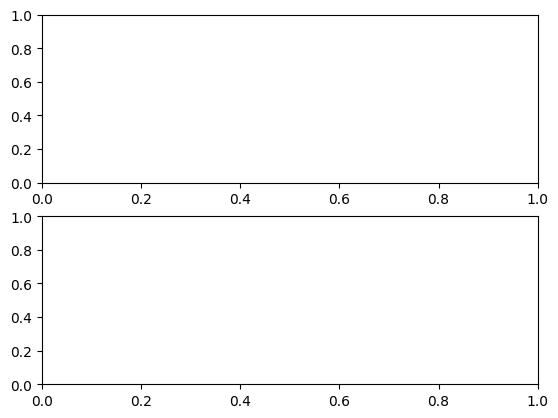

In [ ]:
fig,ax = plt.subplots(2,1)
len(ax.shape)

In [ ]:
mean_by_chain['a']

<xarray.DataArray 'a' (chain: 2)>
array([1.3392929 , 1.34166279])
Coordinates:
  * chain    (chain) int64 0 1

In [ ]:
param_dict = modelPipe.param_dict
sim_output = posterior_predictive(output, model = 'ddm_mic2_leak_no_bias_no_lowdim_noise', chains = 2, draws = 1000, dims = 6)

NameError: name 'posterior_predictive' is not defined

In [ ]:
sim_output[1][sim_output[1]['response'] == 1]

,rt,response
8,1.388387,1.0
59,1.255389,1.0
72,1.083391,1.0
78,1.484388,1.0
91,2.177421,1.0
...,...,...
919,5.240231,1.0
922,2.363429,1.0
934,1.725399,1.0
947,1.825404,1.0


In [ ]:
mean_by_chain = output.posterior.mean(dim='draw').to_dataframe()

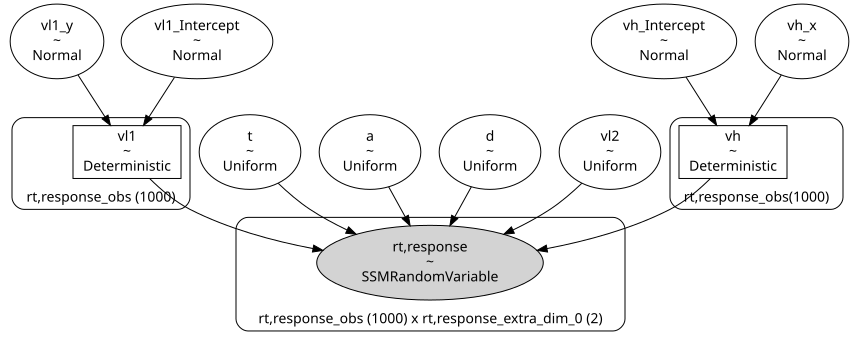

In [ ]:
hssm_unit.graph()

In [ ]:
mean_by_chain

vh_Intercept      vh_x  vl1_Intercept     vl1_y  \
chain rt,response_obs                                                    
0     0                    0.892815  0.196438      -1.302616  0.092475   
      1                    0.892815  0.196438      -1.302616  0.092475   
      2                    0.892815  0.196438      -1.302616  0.092475   
      3                    0.892815  0.196438      -1.302616  0.092475   
      4                    0.892815  0.196438      -1.302616  0.092475   
...                             ...       ...            ...       ...   
1     995                  0.891609  0.195208      -1.310107  0.092398   
      996                  0.891609  0.195208      -1.310107  0.092398   
      997                  0.891609  0.195208      -1.310107  0.092398   
      998                  0.891609  0.195208      -1.310107  0.092398   
      999                  0.891609  0.195208      -1.310107  0.092398   

                              a         d         t       vl2       vl1  
chain rt,response_obs                                                    
0     0                2.220117  0.007097  0.772221 -2.308748 -1.295366  
      1                2.220117  0.007097  0.772221 -2.308748 -1.228861  
      2                2.220117  0.007097  0.772221 -2.308748 -1.280191  
      3                2.220117  0.007097  0.772221 -2.308748 -1.272381  
      4                2.220117  0.007097  0.772221 -2.308748 -1.343911  
...                         ...       ...       ...       ...       ...  
1     995              2.219696  0.007274  0.772194 -2.313356 -1.294977  
      996              2.219696  0.007274  0.772194 -2.313356 -1.234471  
      997              2.219696  0.007274  0.772194 -2.313356 -1.378363  
      998              2.219696  0.007274  0.772194 -2.313356 -1.387236  
      999              2.219696  0.007274  0.772194 -2.313356 -1.325861  

[2000 rows x 9 columns]

In [ ]:
def config_generator():
    '''
    Utils function that transforms the model_config from SSMS output to HSSM

    Returns
    -------
    config_dict: dict
                 
    '''
    model_config = ssms.config.model_config['ddm_mic2_leak_no_bias_no_lowdim_noise']
    bound_dict = {}
    print(model_config['params'])
    for i in range(model_config['n_params']):
        bound_dict[model_config['params'][i]] = (model_config['param_bounds'][0][i], model_config['param_bounds'][1][i])
        print(bound_dict) #tuple of low,high
    config_dict = {}
    config_dict['list_params'] = model_config['params']
    config_dict['bounds'] = bound_dict

    return config_dict


In [ ]:
config_generator()

['vh', 'vl1', 'vl2', 'a', 'd', 't', 'p_outlier']
{'vh': (-4.0, 4.0)}
{'vh': (-4.0, 4.0), 'vl1': (-4.0, 4.0)}
{'vh': (-4.0, 4.0), 'vl1': (-4.0, 4.0), 'vl2': (-4.0, 4.0)}
{'vh': (-4.0, 4.0), 'vl1': (-4.0, 4.0), 'vl2': (-4.0, 4.0), 'a': (0.3, 2.5)}
{'vh': (-4.0, 4.0), 'vl1': (-4.0, 4.0), 'vl2': (-4.0, 4.0), 'a': (0.3, 2.5), 'd': (0.0, 1.0)}
{'vh': (-4.0, 4.0), 'vl1': (-4.0, 4.0), 'vl2': (-4.0, 4.0), 'a': (0.3, 2.5), 'd': (0.0, 1.0), 't': (0.0, 2.0)}


{'list_params': ['vh', 'vl1', 'vl2', 'a', 'd', 't', 'p_outlier'],
 'bounds': {'vh': (-4.0, 4.0),
  'vl1': (-4.0, 4.0),
  'vl2': (-4.0, 4.0),
  'a': (0.3, 2.5),
  'd': (0.0, 1.0),
  't': (0.0, 2.0)}}

In [ ]:
modelPipe.param_dict

{'vh': 0.10378052495910506,
 'vl1': 0.236140724619057,
 'vl2': -2.278358401938018,
 'a': 1.465198743998033,
 'd': 0.03622863922982089,
 't': 0.15637630046246453}

In [ ]:




def parameter_randomiser(model, set_value_dict = None):
    '''
    Function that generates the relevant parameters to feed to release_params
      model: 'ddm_seq2_no_bias' or 'ddm_par2_no_bias'
      set_value_dict: a dictionary of {name, set value} for any parameters you want to fix


    Return:
      parameter_dict: a dictionary of the parameters

    '''

    #Get the parameter list from ssms
    config = ssms.config.model_config[model]
    config_list = config['params']

    param_dict = {}
    for i in range(len(config_list)):
        #Draw a random unif (low,high), then add to dictionary
        param_dict[config_list[i]] = np.random.uniform(config['param_bounds'][0][i], config['param_bounds'][1][i])
    
    #Update the param_dict with set values in the set_value_dict
    if set_value_dict != None:
      for i in set_value_dict.keys():
          param_dict[i] = set_dict[i]

    return param_dict


def release_param(model, path_to_onnx, param_dict, dataset_size=1000, release = None):
    '''Function that generates a dataset, calls HSSM on it with vh as a regressor, while keeping a certain number of other parameters fixed
       in the HSSM call (depending on count).
       
       Parameters
       ----------- 
             model: name of the model as listed in SSMS. 'ddm_mic2_leak_no_bias_no_lowdim_noise'
             path_to_onnx: 
             release: list of parameters being set to scalar
             dataset_size: int, size of the data set.
             param_dict: output of parameter_randomiser()'''

    # #Parse parameters (for now params are kept fixed)
    
    intercept = np.random.uniform(0,1)
    covar_x = np.random.uniform(0,1)
    covar_y = np.random.uniform(0,1)
    regressor_x = np.random.uniform(-1, 1, size=dataset_size)
    regressor_y = np.random.uniform(-1, 1, size=dataset_size)
    vh_vector = intercept + (covar_x * regressor_x) + (covar_y * regressor_y)

    #Edit the param_dict with the new vector

    param_dict['vh'] = vh_vector

    #Simulate 1 data point from every parameter set
    obs_lca = simulator(
    param_dict, model=model, n_samples=1
        )
    #Turn into legible data
    dataset_lca = pd.DataFrame(
    np.column_stack([obs_lca["rts"][:, 0], obs_lca["choices"][:, 0],regressor_x , regressor_y]),

    columns=["rt", "response", "x", "y"],
    )

    dataset_lca = dataset_lca.astype(float)
    
    

    from functools import partial

    #Create the original partial function
    partial_hssm = partial(hssm.HSSM,
    data=dataset_lca,
    model= model,
    include=[
        {
            "name": "vh",
            "prior": {
                "Intercept": {"name": "Uniform", "lower": -4.0, "upper": 4.0},
                "x": {"name": "Normal", "mu": 0, "sigma": 1.0},
                "y": {"name": "Normal", "mu": 0, "sigma": 1.0}
            },
            "formula": "vh ~ 1 + x + y",
            "link": "identity",
        }
    ],
    loglik=path_to_onnx,
    loglik_kind="approx_differentiable",
    model_config={
        "list_params": ['vh', 'vl1', 'vl2', 'a', 't'],
        "bounds": {
            "vh": (-4.0, 4.0),
            "vl1": (-4.0, 4.0),
            "vl2": (-4.0, 4.0),
            "a": (.3, 2.5),
            "t": (0.0, 2.0)
        },
        "backend": 'pytensor'
    },
)
    
    return param_dict

In [ ]:
var_dict = parameter_randomiser('ddm_mic2_leak_no_bias_no_lowdim_noise')

In [ ]:
release_param('ddm_mic2_leak_no_bias_no_lowdim_noise', 0,var_dict)

In [ ]:
def parameter_randomiser(model, set_value_dict):
    '''
    Function that generates the relevant parameters to feed to release_params
      model: 'ddm_seq2_no_bias' or 'ddm_par2_no_bias'
      set_value_dict: a dictionary of {name, set value} for any parameters you want to fix


    Return:
      parameter_dict: a dictionary of the parameters

    '''

    #Get the parameter list from ssms
    config = ssms.config.model_config[model]
    config_list = config['params']

    param_dict = {}
    for i in range(len(config_list)):
        #Draw a random unif (low,high), then add to dictionary
        param_dict[config_list[i]] = np.random.uniform(config['param_bounds'][0][i], config['param_bounds'][1][i])
    
    #Update the param_dict with set values in the set_value_dict
    for i in set_value_dict.keys():
    param_dict[i] = set_dict[i]

    return param_dict


def release_param(model, release, dataset_size, param_dict):
    '''Function that generates a dataset, calls HSSM on it with vh as a regressor, while keeping a certain number of other parameters fixed
       in the HSSM call (depending on count).
       
       Parameters
       ----------- 
             model: 'ddm_seq2_no_bias' or 'ddm_par2_no_bias'.
             release: list of parameters being released.
             dataset_size: int, size of the data set.
             param_dict: output of parameter_randomiser()'''

    # #Parse parameters (for now params are kept fixed)
    
    # VL1 = 1
    # VL2 = 2
    # A = 0.7
    # T = 1.5

    intercept = np.random.uniform(0,1)
    covar_x = np.random.uniform(0,1)
    covar_y = np.random.uniform(0,1)
    regressor_x = np.random.uniform(-1, 1, size=dataset_size)
    regressor_y = np.random.uniform(-1, 1, size=dataset_size)
    vh_vector = intercept + (covar_x * regressor_x) + (covar_y * regressor_y)

    #Edit the param_dict with the new vector

    param_dict['vh'] = vh_vector

    #Call ssms to simulate data

    # vh, vl1, vl2, a, t = [random, 1, 2, 0.7, 1.5]
    obs_lca = simulator(
        param_dict, model=model, n_samples=1
            )


    dataset_lca = pd.DataFrame(
        np.column_stack([obs_lca["rts"][:, 0], obs_lca["choices"][:, 0],regressor_x , regressor_y]),

        columns=["rt", "response", "x", "y"],
        )

    dataset_lca = dataset_lca.astype(float)

    from functools import partial

    #Create the original partial function
    partial_hssm = partial(hssm.HSSM,
    data=dataset_lca,
    model= model,
    include=[
        {
            "name": "vh",
            "prior": {
                "Intercept": {"name": "Uniform", "lower": -4.0, "upper": 4.0},
                "x": {"name": "Normal", "mu": 0, "sigma": 1.0},
                "y": {"name": "Normal", "mu": 0, "sigma": 1.0}
            },
            "formula": "vh ~ 1 + x + y",
            "link": "identity",
        }
    ],
    loglik='/users/avo2/data/avo2/tsumme_data/seq2_no_bias',
    loglik_kind="approx_differentiable",
    model_config={
        "list_params": ['vh', 'vl1', 'vl2', 'a', 't'],
        "bounds": {
            "vh": (-4.0, 4.0),
            "vl1": (-4.0, 4.0),
            "vl2": (-4.0, 4.0),
            "a": (.3, 2.5),
            "t": (0.0, 2.0)
        },
        "backend": 'pytensor'
    },
)
    #Generate the dictionary to feed into the partial function
    newDict = {}
    for i in release:
        if i in paramDict.keys():
            newDict.update({i: paramDict[i]})

    #Create HSSM model
    partial_model = partial_hssm(**newDict)

    #Sample
    output = partial_model.sample(sampler = 'nuts_numpyro', chains=1, cores=1, draws=1000, tune=500)
    
    return output, partial_model
    # #Save the trace
    # with open('/users/avo2/data/avo2/tsumme_data/regression/test.pickle', 'wb') as handle:
    #     pickle.dump(output, handle)
    
    

In [ ]:
output = model_hssm.sample(sampler = 'nuts_numpyro', chains=1, cores=1, draws=1000, tune=500)

Compiling...


Compilation time = 0:00:01.325164
Sampling...
sample: 100%|██████████| 1500/1500 [00:51<00:00, 29.33it/s, 7 steps of size 4.69e-01. acc. prob=0.92] 
Sampling time = 0:00:51.427973
Transforming variables...
Transformation time = 0:00:00.467370


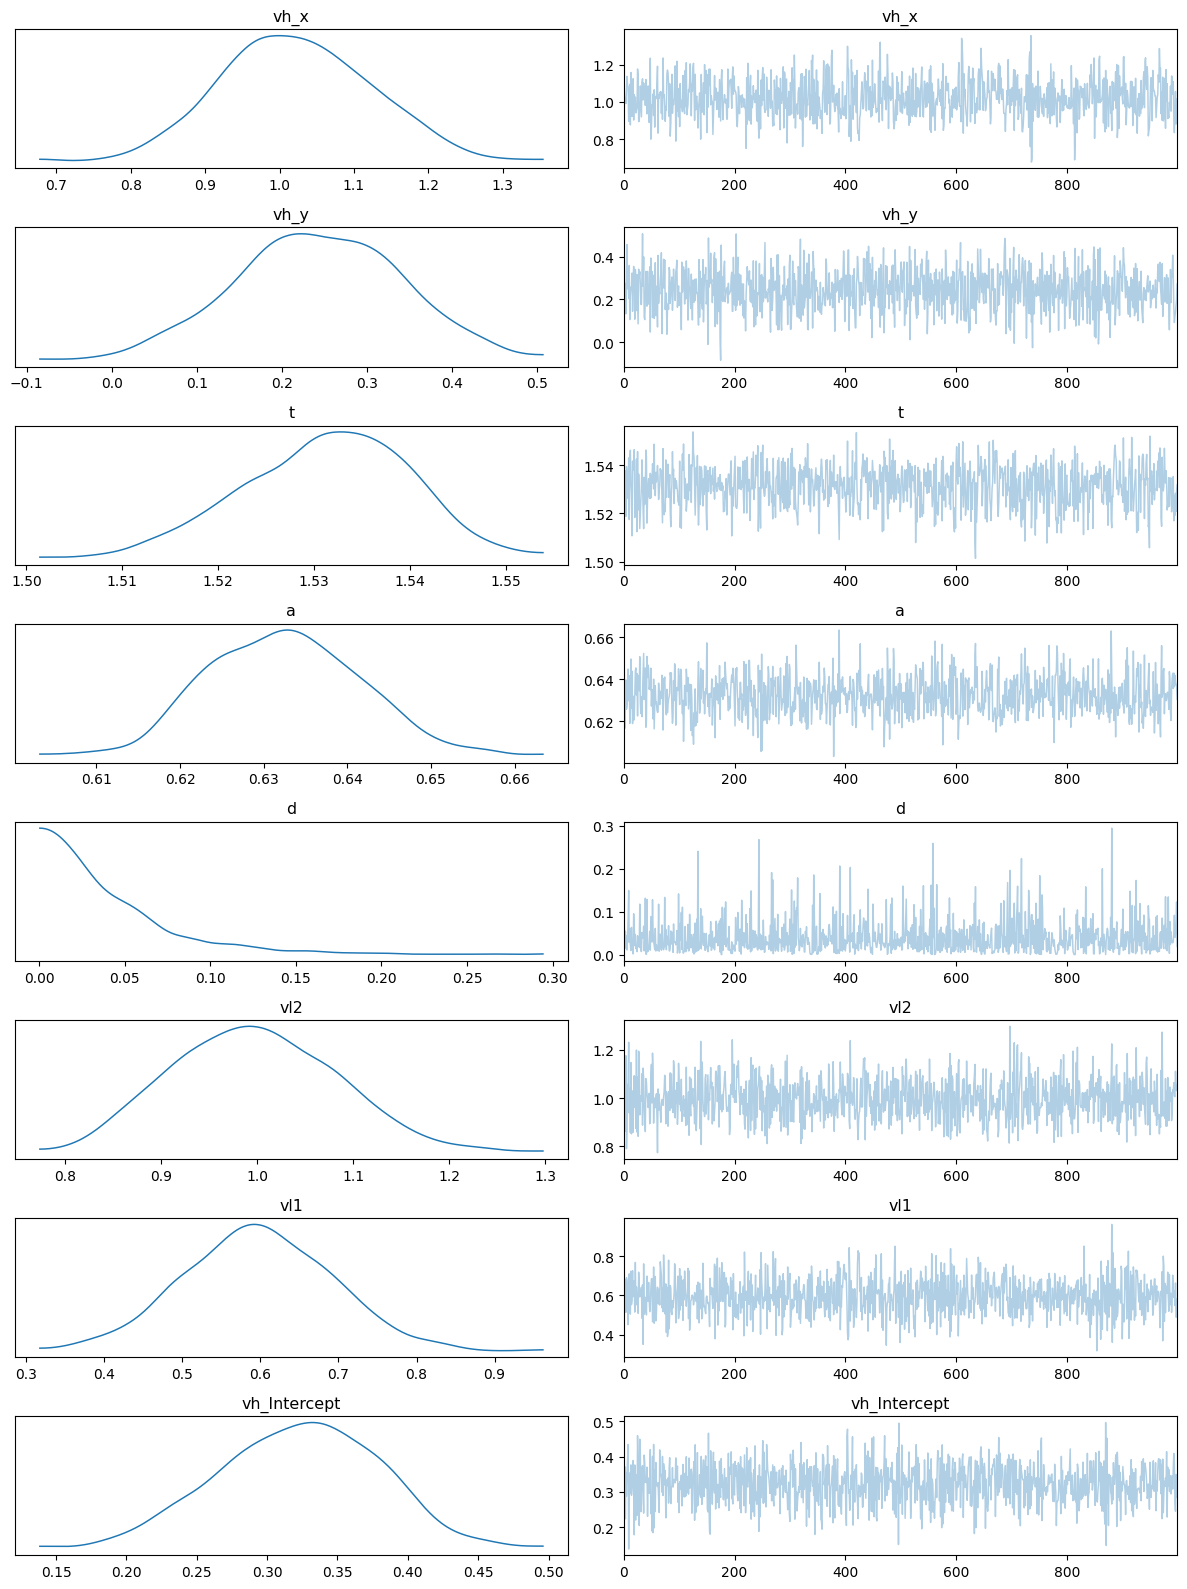

In [ ]:
import arviz as az
az.plot_trace(output)
plt.tight_layout()